In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from evaluation_util import evaluate_on_dataset
from utils import plt_legend

import warnings
warnings.filterwarnings('ignore')

ryp2 is not installed. Install with pip install rpy2 to run tools with R support.

/home/icb/yuge.ji/miniconda3/envs/pertpy_clean2/lib/python3.10/site-packages/lightning_utilities/core/imports.py:14: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/home/icb/yuge.ji/miniconda3/envs/pertpy_clean2/lib/python3.10/site-packages/lightning_fabric/__init__.py:40: Deprecated call to `pkg_resources.declare_namespace('lightning_fabric')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
/home/icb/yuge.ji/miniconda3/envs/pertpy_clean2/lib/python3.10/site-packages/pytorch_lightning/__init__.py:37: Deprecated call to `pkg_resources.declare_namespace('pytorch_lightning')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/r

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
distances = [
    "mse",
    "mmd",
    "euclidean",
    "edistance",
    "ks_test",
    "mean_absolute_error",
    "t_test",
    "cosine_distance",
    "pearson_distance",
    "r2_distance",
    "mmd_rbf",
    "classifier_proba",
    "classifier_cp",
    "kendalltau_distance",
    "spearman_distance",
    "wasserstein",
    "sym_kldiv"
]

distance_map = {
    "euclidean": "Euclidean",
    "spearman_distance": "Spearman",
    "mean_absolute_error": "mean absolute error",
    "r2_distance": "R2",
    "pearson_distance": "Pearson",
    "mse": "MSE",
    "cosine_distance": "cosine distance",
    "edistance": "E-distance",
    "sym_kldiv": "symmetric KL div.",
    "mmd": "MMD linear",
    "mmd_rbf": "MMD RBF",
    "ks_test": "KS statistic",
    "t_test": "T-test",
    "wasserstein": "Wasserstein",
    "classifier_proba": "classifier proba",
    "classifier_cp": "classifier class projection",
    "kendalltau_distance": "Kendall tau distance"
}

In [4]:
# for simulated metadata
sim_path = "./data/sim_files/sim_files/splatter_sim"
params = pd.read_csv(f"{sim_path}/splatter_sim_params.csv").reset_index()
params["perturbation"] = [f"Path{x}" for x in params["index"].values]
params.perturbation.replace({"Path1": "control"}, inplace=True)

In [30]:
# ------------------------------------------------------------------
# 2. ANNOTATION FUNCTIONS (ONE PER DATASET FAMILY)
# ------------------------------------------------------------------

def annotate_simulated(df: pd.DataFrame) -> None:
    """Add simulation parameters per perturbation, drop fake controls."""
    for col in params.columns:
        mapping = dict(zip(params["perturbation"], params[col]))
        df[col] = df["perturbation"].map(mapping)
    # matches notebook: df = df.dropna()
    df.dropna(inplace=True)


def annotate_garcia(df: pd.DataFrame) -> None:
    """Add pcw label (pathway control weight)."""
    df["pcw"] = [float(p) if "control" not in p else 8.6 for p in df.perturbation]


def annotate_schiebinger(df: pd.DataFrame) -> None:
    """Add time-point label (day)."""
    df["day"] = [float(p[1:]) if "D" in p else 0 for p in df.perturbation]


def annotate_satinha(df: pd.DataFrame) -> None:
    """No real ground truth; constant n_guides as in notebook."""
    df["n_guides"] = 1


def annotate_norman(df: pd.DataFrame) -> None:
    """Number of guides per perturbation (count '+' and add 1)."""
    df["n_guides"] = [int(s.count("+")) + 1 for s in df.perturbation]


def annotate_sciplex(df: pd.DataFrame) -> None:
    """Dose and log10(dose) from perturbation name."""
    df["dose"] = [0 if "control" in x else float(x.split("_")[1])
                  for x in df.perturbation]
    df["log(dose)"] = [0 if "control" in x else np.log10(float(x.split("_")[1]))
                       for x in df.perturbation]


def annotate_tahoe(df: pd.DataFrame) -> None:
    """Dose and log10(dose) for Tahoe datasets (same scheme as sciplex)."""
    df["dose"] = [0 if "control" in x else float(x.split("_")[1])
                  for x in df.perturbation]
    df["log(dose)"] = [0 if "control" in x else np.log10(float(x.split("_")[1]))
                       for x in df.perturbation]


def annotate_mcfarland(df: pd.DataFrame) -> None:
    """Time label extracted from perturbation string."""
    df["time"] = [0 if "control" in p else p.split("_")[1]
                  for p in df.perturbation]


# ------------------------------------------------------------------
# 3. DATASET CONFIG (DIRECTLY MIRRORS THE NOTEBOOK)
# ------------------------------------------------------------------
def ds(name, annotate, ground_truth, optimal_distance, suffix='_sub'):
    return {
        "pkl": f"{name}{suffix}.pkl",
        "annotate": annotate,
        "ground_truth": ground_truth,
        "optimal_distance": optimal_distance,
    }

DATASETS = {
    "simulated": ds("sim", annotate_simulated, "DEProb", "ks_test"),
    "garcia": ds("garcia", annotate_garcia, "pcw", "kendalltau_distance"),
    "schiebinger": ds("schiebinger", annotate_schiebinger, "day", "kendalltau_distance"),
    "satinha": ds("satinha", annotate_satinha, "n_guides", "edistance"),
    "norman": ds("norman", annotate_norman, "n_guides", "edistance"),

    "sciplex_MCF7": ds("spMCF7", annotate_sciplex, "log(dose)", "t_test"),
    "sciplex_A549": ds("spA549", annotate_sciplex, "log(dose)", "r2_distance"),
    "sciplex_K562": ds("spK562", annotate_sciplex, "log(dose)", "wasserstein"),

    "tahoeA549": ds("tahoe", annotate_tahoe, "dose", "kendalltau_distance"),
    "tahoeHT29": ds("tahoeHT29", annotate_tahoe, "dose", "kendalltau_distance"),
    "tahoeBT474": ds("tahoeBT474", annotate_tahoe, "dose", "kendalltau_distance"),

    "mcfarland": ds("mcfarland", annotate_mcfarland, "time", "mean_absolute_error"),
}

DATASETS_ALL = {
    "simulated": ds("sim", annotate_simulated, "DEProb", "ks_test", ""),
    "garcia": ds("garcia", annotate_garcia, "pcw", "kendalltau_distance", ""),
    "schiebinger": ds("schiebinger", annotate_schiebinger, "day", "kendalltau_distance", ""),
#     "satinha": ds("satinha", annotate_satinha, "n_guides", "edistance", ""),
    "norman": ds("norman", annotate_norman, "n_guides", "edistance", ""),

    "sciplex_MCF7": ds("spMCF7", annotate_sciplex, "log(dose)", "t_test", ""),
    "sciplex_A549": ds("spA549", annotate_sciplex, "log(dose)", "r2_distance", ""),
    "sciplex_K562": ds("spK562", annotate_sciplex, "log(dose)", "wasserstein", ""),

    "tahoeA549": ds("tahoe", annotate_tahoe, "dose", "kendalltau_distance", ""),
    "tahoeHT29": ds("tahoeHT29", annotate_tahoe, "dose", "kendalltau_distance", ""),
    "tahoeBT474": ds("tahoeBT474", annotate_tahoe, "dose", "kendalltau_distance", ""),

    "mcfarland": ds("mcfarland", annotate_mcfarland, "time", "mean_absolute_error", ""),
}

In [6]:
def performances_to_result_df(performances):
    # stack all per-dataset performance tables
    dfs = []
    for ds_name, res_df in performances.items():
        dfs.append(res_df.add_suffix(f"_{ds_name}"))

    df = pd.concat(dfs, axis=1)  # rows = metrics, columns = (measure × dataset)

    # normalize each column to [0, 1]
    ndf = df.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)

    # sort values by previous order
    ndf = ndf.loc[distances]

    # build the three groups: PDR, Robustness, BioRep
    sub_dfs = []

    cols_pdr = [c for c in ndf.columns if "sensitivity" in c]
    sub_dfs.append(ndf[cols_pdr])

    cols_rob = [c for c in ndf.columns if "robustness" in c]
    sub_dfs.append(ndf[cols_rob])

    cols_biorep = [c for c in ndf.columns if "sens" not in c and "robu" not in c]
    sub_dfs.append(ndf[cols_biorep])

    def per_eval_pointplot(df, figsize=(4, 6)):
        df = df.round(3)
        df = df.reset_index(names="distance").melt(
            id_vars="distance",
            var_name="criterion",
            value_name="score",
        )

        plt.figure(figsize=figsize)
        sns.pointplot(
            data=df,
            x="score",
            y="distance",
            hue="criterion",
            hue_order=["PDR", "Robustness", "BioRep"],
            join=False,
            markers=["o", "s", "D"],
            markerfacecolor="none",
        )
        plt.xlabel("z-normalized per evaluation measure score")

    # summarize across datasets before z-normalization
    summary_df = pd.concat(
        [sub.mean(axis=1) for sub in sub_dfs],
        axis=1,
    ).set_axis(["PDR", "Robustness", "BioRep"], axis=1)

    summary_df = summary_df.round(3)

    # z-normalize for plotting / final output
    zdf = (summary_df - summary_df.mean()) / summary_df.std(ddof=0)

    per_eval_pointplot(zdf, figsize=(6, 6))
    plt.title("All datasets")
    plt.show()

    return zdf, df

## effect of different cell numbers

In [49]:
def retrieve_individual_performances(dss_path):
    performances = {}

    for name, cfg in DATASETS_ALL.items():
        print('retrieving', f"{dss_path}/{cfg['pkl']}")
        with open(f"{dss_path}/{cfg['pkl']}", "rb") as f:
            results = pickle.load(f)
            
        # grab all available for those runs using lognorm and varying n_cells
        avail = [k for k in results.keys() if 'n_cells' in k]
        
        for k in avail:
            n_cells = k.split('-')[0]

            perf_df = evaluate_on_dataset(
                results,
                cfg["annotate"],
                cfg["ground_truth"],
                optimal_distance=cfg["optimal_distance"],
                rep='lognorm',
                exp='n_cells',
                numeric_value=n_cells,
                plot_performance=False
            )
            performances[name+'_'+n_cells] = perf_df

    return performances

In [50]:
%%time
performances = retrieve_individual_performances("/lustre/scratch/users/yuge.ji/metrics_revisions")

retrieving /lustre/scratch/users/yuge.ji/metrics_revisions/sim.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics_revisions/garcia.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics_revisions/schiebinger.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics_revisions/norman.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics_revisions/spMCF7.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics_revisions/spA549.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics_revisions/spK562.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics_revisions/tahoe.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics_revisions/tahoeHT29.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics_revisions/tahoeBT474.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics_revisions/mcfarland.pkl
CPU times: user 2min 25s, sys: 179 ms, total: 2min 25s
Wall time: 2min 28s


In [51]:
performances.keys()

dict_keys(['simulated_10', 'simulated_20', 'simulated_30', 'simulated_50', 'simulated_70', 'simulated_100', 'simulated_150', 'simulated_200', 'simulated_250', 'simulated_300', 'simulated_350', 'simulated_400', 'garcia_100', 'garcia_150', 'garcia_200', 'garcia_250', 'garcia_300', 'garcia_10', 'garcia_20', 'garcia_30', 'garcia_50', 'garcia_70', 'schiebinger_100', 'schiebinger_150', 'schiebinger_200', 'schiebinger_250', 'schiebinger_300', 'schiebinger_350', 'schiebinger_400', 'schiebinger_10', 'schiebinger_20', 'schiebinger_30', 'schiebinger_50', 'schiebinger_70', 'norman_100', 'norman_150', 'norman_200', 'norman_250', 'norman_300', 'norman_350', 'norman_390', 'norman_10', 'norman_20', 'norman_30', 'norman_50', 'norman_70', 'sciplex_MCF7_100', 'sciplex_MCF7_150', 'sciplex_MCF7_200', 'sciplex_MCF7_250', 'sciplex_MCF7_270', 'sciplex_MCF7_10', 'sciplex_MCF7_20', 'sciplex_MCF7_30', 'sciplex_MCF7_50', 'sciplex_MCF7_70', 'sciplex_A549_100', 'sciplex_A549_150', 'sciplex_A549_200', 'sciplex_A549_

In [36]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # example:
# # performances['garcia_100']['sensitivity'].loc['mmd_rbf']


# for metric_name in ["robustness", "sensitivity"]:
#     rows = []
#     for key, result in performances.items():
#         dataset, n = key.rsplit("_", 1)
#         for distance_name in [
#             "mmd_rbf", "wasserstein", "ks_test", "r2_distance", "sym_kldiv",
#             "classifier_proba", "euclidean", "cosine_distance", "mse",
#             "pearson_distance", "spearman_distance", "mmd", "mean_absolute_error",
#             "edistance", "classifier_cp", "t_test", "kendalltau_distance",
#         ]:
#             rows.append({
#                 "dataset": dataset,
#                 "n": int(n),
#                 "distance": distance_name,
#                 "value": result[metric_name].loc[distance_name],
#             })

#     plot_df = pd.DataFrame(rows)

#     g = sns.relplot(
#         data=plot_df,
#         x="n",
#         y="value",
#         hue="distance",
#         kind="line",
#         col="dataset",
#         col_wrap=4,
#         marker="o",
#         height=4,
#         aspect=1.2,
#         facet_kws={"sharey": False, "sharex": True},
#     )

#     g.set_axis_labels("n cells", metric_name)
#     g.set_titles("{col_name}")
#     g.fig.suptitle(f"{metric_name} across all distances, per dataset", y=1.02)

#     plt.show()

# #         df = pd.DataFrame(rows).sort_values(["dataset", "n"])

# #         for dataset, subdf in df.groupby("dataset"):
# #             plt.plot(subdf["n"], subdf["value"], marker="o", label=dataset)

# #         plt.xlabel("Number")
# #         plt.ylabel(f"{metric_name}: {distance_name}")
# #         plt.legend()
# #         plt.tight_layout()
# #         plt.show()

In [52]:
# identify distances which do or do no plateau w.r.t. cell count

def identify_pmax_by_marginal_gain(
    df,
    perf_col="rank",
    metric_col="metric",
    n_col="n_cells",
    marginal_frac=0.05,
    require_consecutive=2,
    threshold_mode="relative",   # "relative" or "absolute"
    perf_range=1.0,              # used when threshold_mode="absolute"
):
    df = df.copy()
    df[n_col] = pd.to_numeric(df[n_col], errors="coerce")
    df[perf_col] = pd.to_numeric(df[perf_col], errors="coerce")
    df = df.dropna(subset=[metric_col, n_col, perf_col])

    curve_df = (
        df.groupby([metric_col, n_col], as_index=False)[perf_col]
          .mean()
          .sort_values([metric_col, n_col])
          .reset_index(drop=True)
    )

    all_curves = []
    summaries = []

    for metric, g in curve_df.groupby(metric_col, sort=False):
        g = g.sort_values(n_col).copy()

        # lower is better
        g["delta_perf"] = g[perf_col].shift(1) - g[perf_col]
        g["delta_n"] = g[n_col] - g[n_col].shift(1)
    
        total_observed_gain = g[perf_col].iloc[0] - g[perf_col].iloc[-1]

        if threshold_mode == "relative":
            marginal_gain_threshold = marginal_frac * total_observed_gain
        elif threshold_mode == "absolute":
            marginal_gain_threshold = marginal_frac * perf_range
        else:
            raise ValueError("threshold_mode must be 'relative' or 'absolute'")

        overall_gets_worse = total_observed_gain <= 0

        if overall_gets_worse:
            g["is_marginal"] = False
            plateau_found = False
            plateau_start_n = np.nan
            pmax = np.nan
            plateau_n_values = []
        else:
            g["is_marginal"] = g["delta_perf"] <= marginal_gain_threshold

            plateau_start_idx = None
            vals = g["is_marginal"].fillna(False).to_numpy()

            for i in range(1, len(g)):
                end = i + require_consecutive
                if end <= len(g) and vals[i:end].all():
                    plateau_start_idx = i
                    break

            if plateau_start_idx is None:
                plateau_found = False
                plateau_start_n = np.nan
                pmax = np.nan
                plateau_n_values = []
            else:
                plateau_found = True
                plateau_start_n = g.iloc[plateau_start_idx][n_col]
                plateau_region = g.loc[g[n_col] >= plateau_start_n, perf_col]
                pmax = plateau_region.mean()
                plateau_n_values = g.loc[g[n_col] >= plateau_start_n, n_col].tolist()

        g["plateau_found"] = plateau_found
        g["plateau_start_n"] = plateau_start_n
        g["pmax"] = pmax
        g["overall_gets_worse"] = overall_gets_worse
        g["threshold_mode"] = threshold_mode
        g["marginal_gain_threshold"] = marginal_gain_threshold

        all_curves.append(g)

        summaries.append({
            metric_col: metric,
            "plateau_found": plateau_found,
            "overall_gets_worse": overall_gets_worse,
            "plateau_start_n": plateau_start_n,
            "pmax": pmax,
            "total_observed_gain": total_observed_gain,
            "threshold_mode": threshold_mode,
            "marginal_gain_threshold": marginal_gain_threshold,
            "plateau_n_values": plateau_n_values,
        })

    summary_df = pd.DataFrame(summaries)
    curve_df = pd.concat(all_curves, ignore_index=True)
    return summary_df, curve_df

<Figure size 1000x500 with 0 Axes>

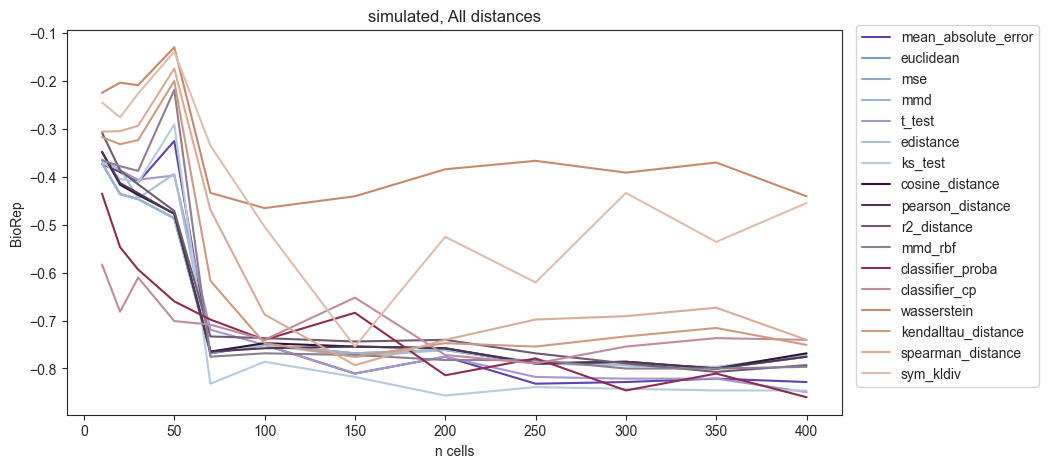

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


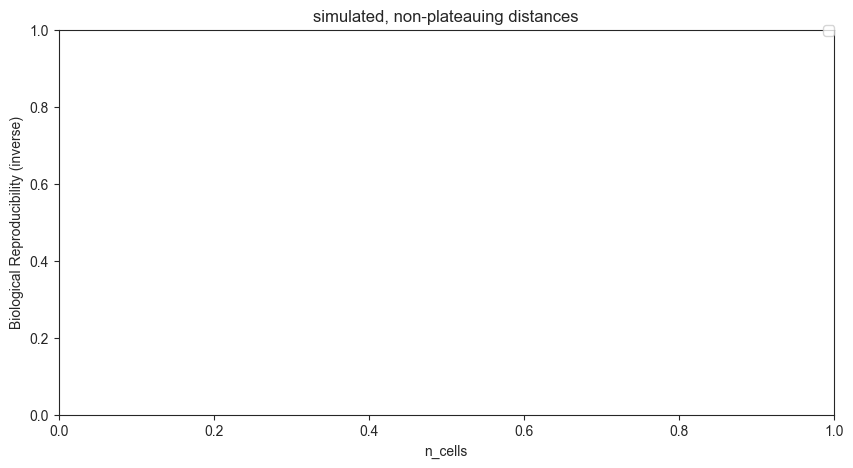

,metric,plateau_found,overall_gets_worse,plateau_start_n,pmax,total_observed_gain,threshold_mode,marginal_gain_threshold,plateau_n_values
0,mean_absolute_error,True,False,20,-0.685551,0.454909,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
1,euclidean,True,False,30,-0.713958,0.403802,absolute,0.05,"[30, 50, 70, 100, 150, 200, 250, 300, 350, 400]"
2,mse,True,False,30,-0.713606,0.403802,absolute,0.05,"[30, 50, 70, 100, 150, 200, 250, 300, 350, 400]"
3,mmd,True,False,30,-0.713606,0.403802,absolute,0.05,"[30, 50, 70, 100, 150, 200, 250, 300, 350, 400]"
4,t_test,True,False,20,-0.686808,0.485742,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
5,edistance,True,False,100,-0.776405,0.400277,absolute,0.05,"[100, 150, 200, 250, 300, 350, 400]"
6,ks_test,True,False,20,-0.706460,0.482218,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
7,cosine_distance,True,False,30,-0.708232,0.420528,absolute,0.05,"[30, 50, 70, 100, 150, 200, 250, 300, 350, 400]"
8,pearson_distance,True,False,30,-0.709686,0.427577,absolute,0.05,"[30, 50, 70, 100, 150, 200, 250, 300, 350, 400]"
9,r2_distance,True,False,100,-0.768349,0.485705,absolute,0.05,"[100, 150, 200, 250, 300, 350, 400]"


<Figure size 1000x500 with 0 Axes>

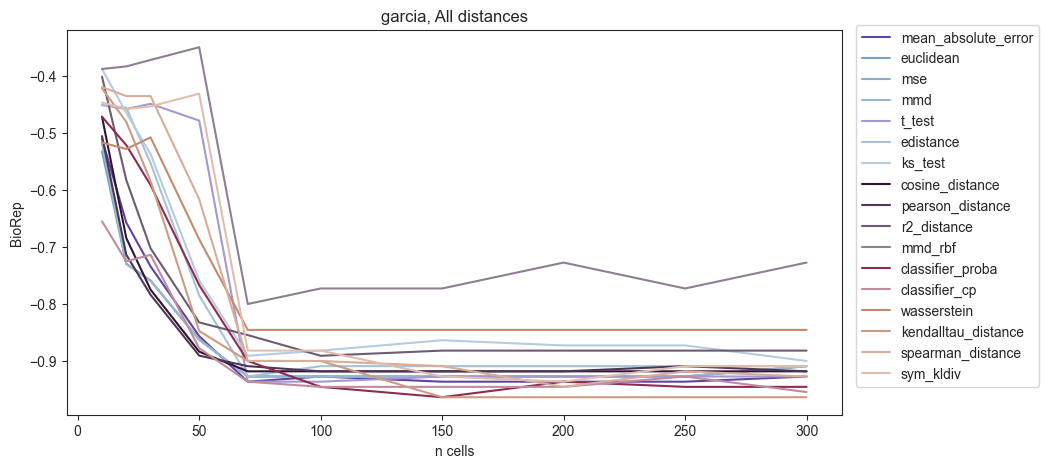

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


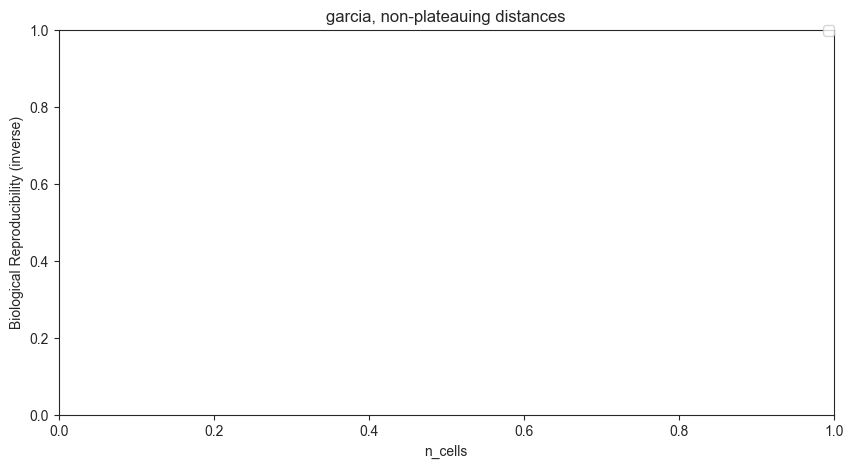

,metric,plateau_found,overall_gets_worse,plateau_start_n,pmax,total_observed_gain,threshold_mode,marginal_gain_threshold,plateau_n_values
0,mean_absolute_error,True,False,100,-0.932727,0.417500,absolute,0.05,"[100, 150, 200, 250, 300]"
1,euclidean,True,False,100,-0.923636,0.376661,absolute,0.05,"[100, 150, 200, 250, 300]"
2,mse,True,False,100,-0.923636,0.392521,absolute,0.05,"[100, 150, 200, 250, 300]"
3,mmd,True,False,100,-0.923636,0.392521,absolute,0.05,"[100, 150, 200, 250, 300]"
4,t_test,True,False,20,-0.774012,0.476407,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
5,edistance,True,False,100,-0.909091,0.458225,absolute,0.05,"[100, 150, 200, 250, 300]"
6,ks_test,True,False,100,-0.878182,0.512572,absolute,0.05,"[100, 150, 200, 250, 300]"
7,cosine_distance,True,False,70,-0.918182,0.446925,absolute,0.05,"[70, 100, 150, 200, 250, 300]"
8,pearson_distance,True,False,70,-0.915152,0.412940,absolute,0.05,"[70, 100, 150, 200, 250, 300]"
9,r2_distance,True,False,70,-0.878788,0.480797,absolute,0.05,"[70, 100, 150, 200, 250, 300]"


<Figure size 1000x500 with 0 Axes>

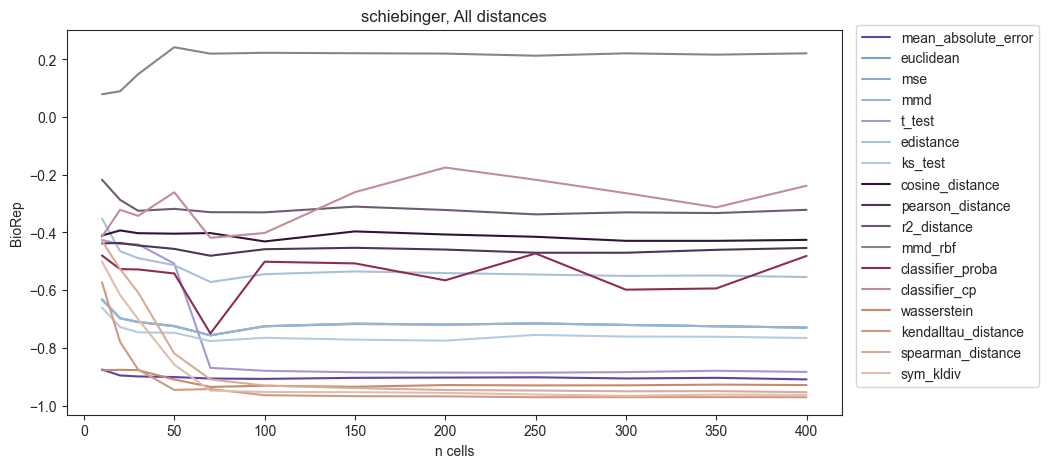

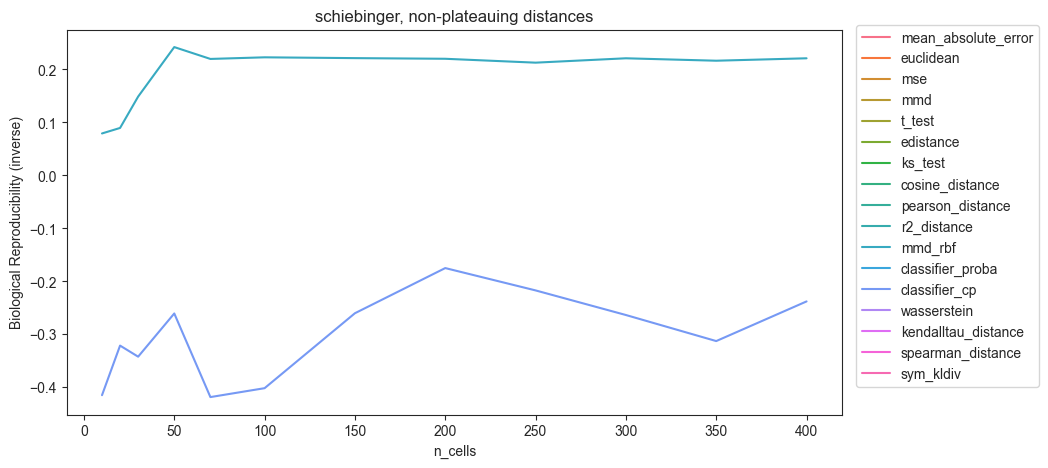

,metric,plateau_found,overall_gets_worse,plateau_start_n,pmax,total_observed_gain,threshold_mode,marginal_gain_threshold,plateau_n_values
0,mean_absolute_error,True,False,20.0,-0.903628,0.034356,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
1,euclidean,True,False,30.0,-0.724695,0.097302,absolute,0.05,"[30, 50, 70, 100, 150, 200, 250, 300, 350, 400]"
2,mse,True,False,30.0,-0.724380,0.097302,absolute,0.05,"[30, 50, 70, 100, 150, 200, 250, 300, 350, 400]"
3,mmd,True,False,30.0,-0.724380,0.097302,absolute,0.05,"[30, 50, 70, 100, 150, 200, 250, 300, 350, 400]"
4,t_test,True,False,20.0,-0.767576,0.457281,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
5,edistance,True,False,30.0,-0.539625,0.202483,absolute,0.05,"[30, 50, 70, 100, 150, 200, 250, 300, 350, 400]"
6,ks_test,True,False,30.0,-0.762680,0.105027,absolute,0.05,"[30, 50, 70, 100, 150, 200, 250, 300, 350, 400]"
7,cosine_distance,True,False,20.0,-0.412435,0.015030,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
8,pearson_distance,True,False,20.0,-0.458704,0.015727,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
9,r2_distance,True,False,30.0,-0.325912,0.104196,absolute,0.05,"[30, 50, 70, 100, 150, 200, 250, 300, 350, 400]"


<Figure size 1000x500 with 0 Axes>

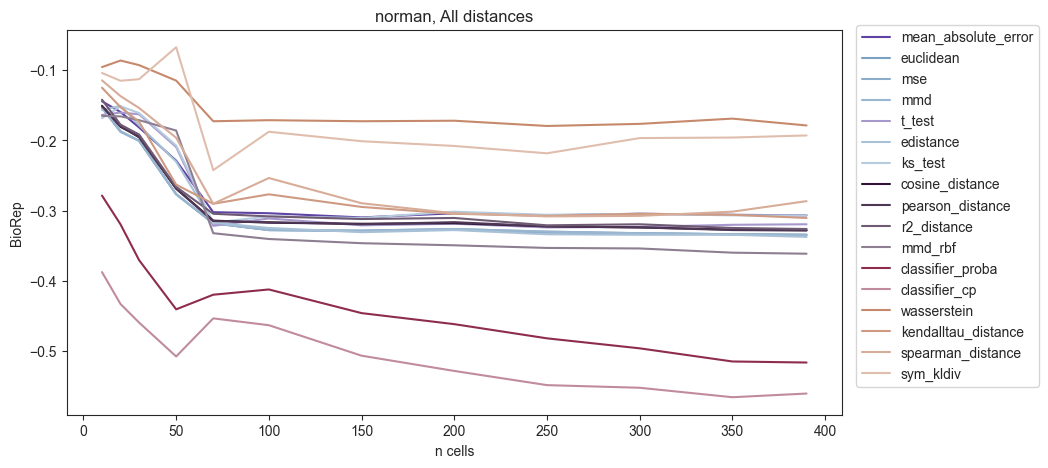

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


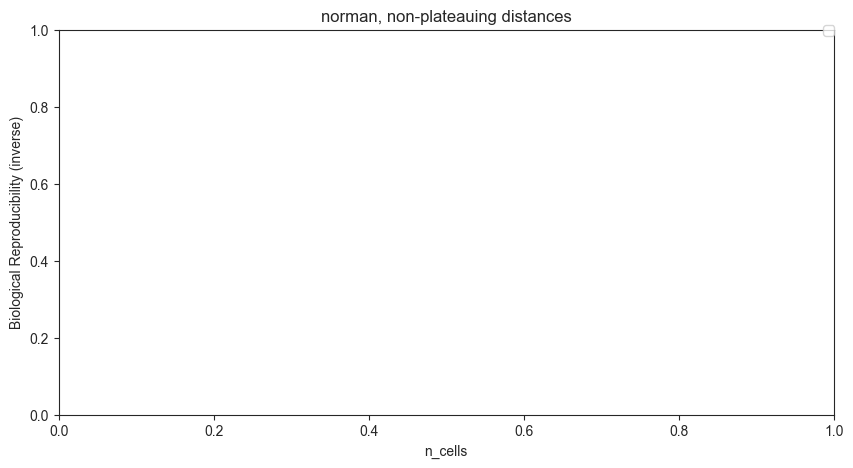

,metric,plateau_found,overall_gets_worse,plateau_start_n,pmax,total_observed_gain,threshold_mode,marginal_gain_threshold,plateau_n_values
0,mean_absolute_error,True,False,20,-0.273922,0.162548,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
1,euclidean,True,False,20,-0.299879,0.180900,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
2,mse,True,False,20,-0.299525,0.181274,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
3,mmd,True,False,20,-0.299530,0.181274,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
4,t_test,True,False,20,-0.281081,0.155807,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
5,edistance,True,False,20,-0.290891,0.180713,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
6,ks_test,True,False,20,-0.270994,0.138392,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
7,cosine_distance,True,False,20,-0.292078,0.177154,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
8,pearson_distance,True,False,20,-0.292197,0.177154,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."
9,r2_distance,True,False,20,-0.287430,0.184270,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300, 350,..."


<Figure size 1000x500 with 0 Axes>

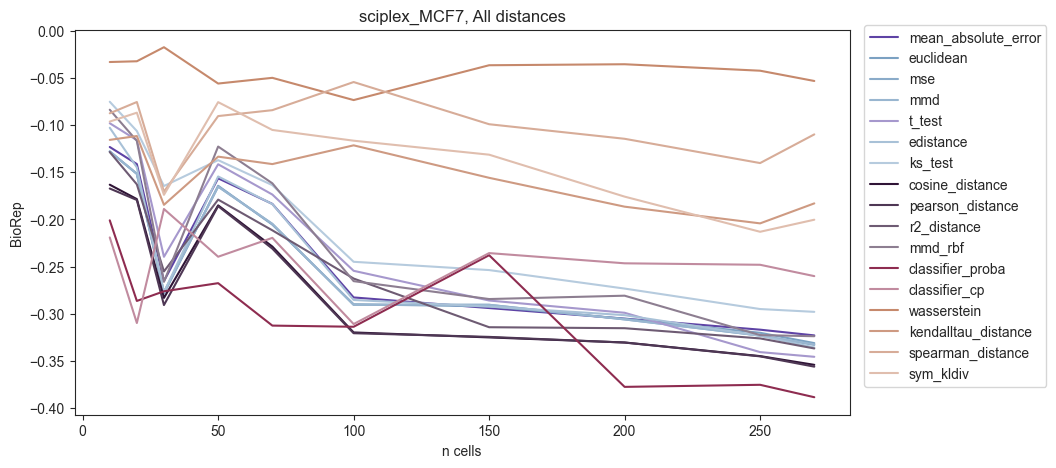

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


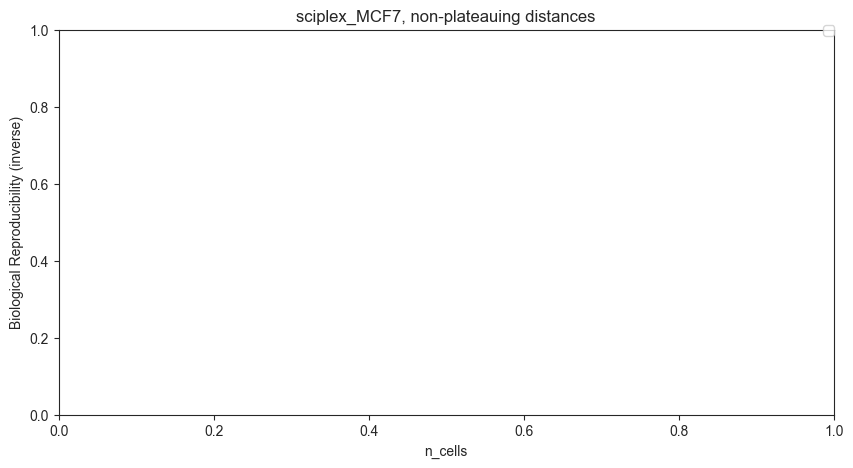

,metric,plateau_found,overall_gets_worse,plateau_start_n,pmax,total_observed_gain,threshold_mode,marginal_gain_threshold,plateau_n_values
0,mean_absolute_error,True,False,50,-0.265916,0.199745,absolute,0.05,"[50, 70, 100, 150, 200, 250, 270]"
1,euclidean,True,False,50,-0.272631,0.203146,absolute,0.05,"[50, 70, 100, 150, 200, 250, 270]"
2,mse,True,False,50,-0.273291,0.205090,absolute,0.05,"[50, 70, 100, 150, 200, 250, 270]"
3,mmd,True,False,50,-0.273185,0.204493,absolute,0.05,"[50, 70, 100, 150, 200, 250, 270]"
4,t_test,True,False,50,-0.262947,0.247615,absolute,0.05,"[50, 70, 100, 150, 200, 250, 270]"
5,edistance,True,False,50,-0.268057,0.232948,absolute,0.05,"[50, 70, 100, 150, 200, 250, 270]"
6,ks_test,True,False,50,-0.237931,0.222760,absolute,0.05,"[50, 70, 100, 150, 200, 250, 270]"
7,cosine_distance,True,False,50,-0.298297,0.190996,absolute,0.05,"[50, 70, 100, 150, 200, 250, 270]"
8,pearson_distance,True,False,50,-0.299098,0.188848,absolute,0.05,"[50, 70, 100, 150, 200, 250, 270]"
9,r2_distance,True,False,50,-0.277943,0.208212,absolute,0.05,"[50, 70, 100, 150, 200, 250, 270]"


<Figure size 1000x500 with 0 Axes>

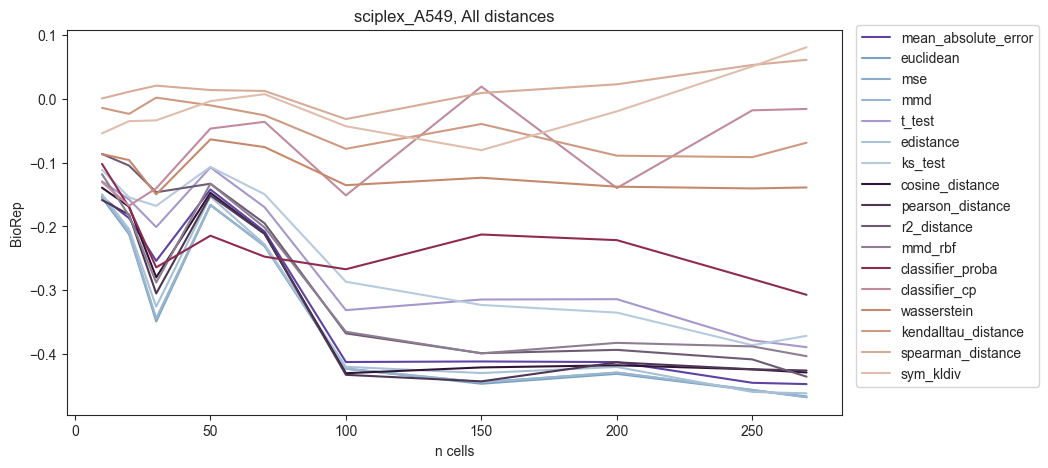

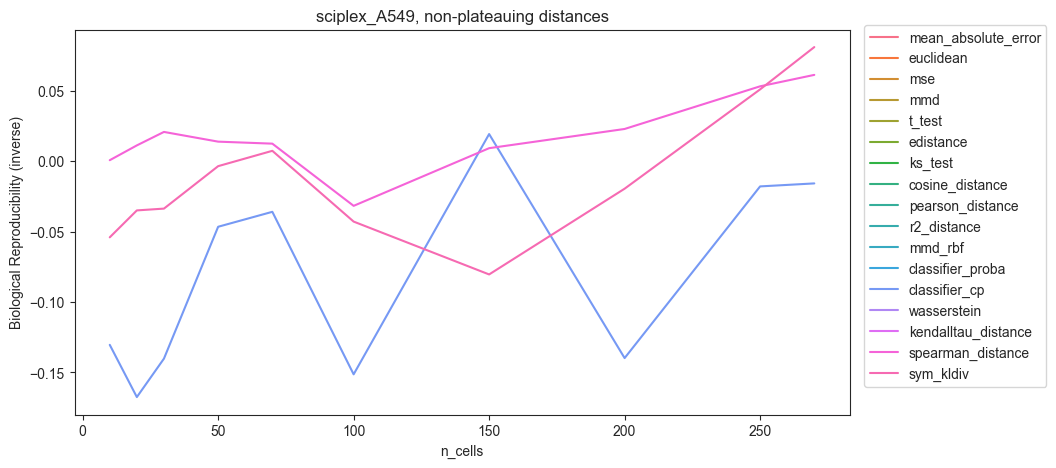

,metric,plateau_found,overall_gets_worse,plateau_start_n,pmax,total_observed_gain,threshold_mode,marginal_gain_threshold,plateau_n_values
0,mean_absolute_error,True,False,150.0,-0.429139,0.293308,absolute,0.05,"[150, 200, 250, 270]"
1,euclidean,True,False,150.0,-0.450268,0.311387,absolute,0.05,"[150, 200, 250, 270]"
2,mse,True,False,150.0,-0.449364,0.315830,absolute,0.05,"[150, 200, 250, 270]"
3,mmd,True,False,150.0,-0.449364,0.315830,absolute,0.05,"[150, 200, 250, 270]"
4,t_test,True,False,20.0,-0.262624,0.259970,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 270]"
5,edistance,True,False,150.0,-0.442802,0.312056,absolute,0.05,"[150, 200, 250, 270]"
6,ks_test,True,False,20.0,-0.253457,0.260251,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 270]"
7,cosine_distance,True,False,150.0,-0.422915,0.289642,absolute,0.05,"[150, 200, 250, 270]"
8,pearson_distance,True,False,150.0,-0.426414,0.267252,absolute,0.05,"[150, 200, 250, 270]"
9,r2_distance,True,False,20.0,-0.286997,0.349097,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 270]"


<Figure size 1000x500 with 0 Axes>

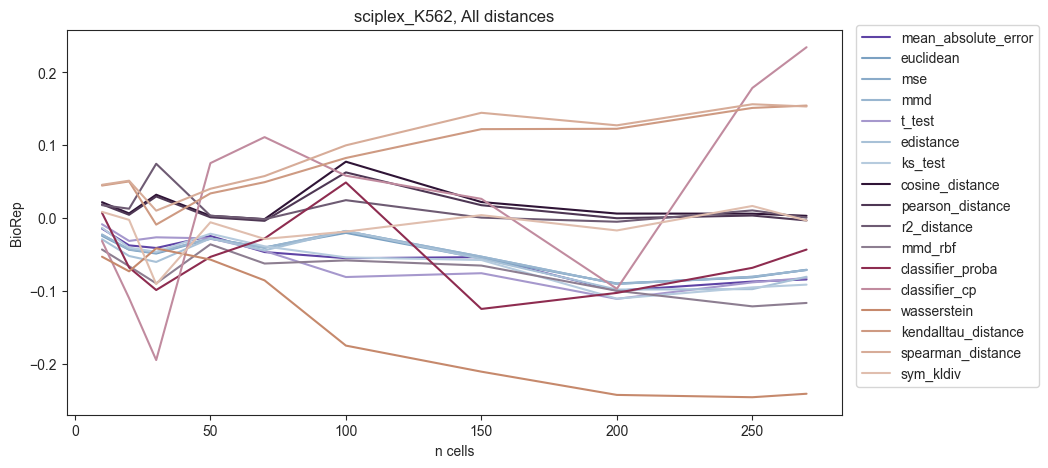

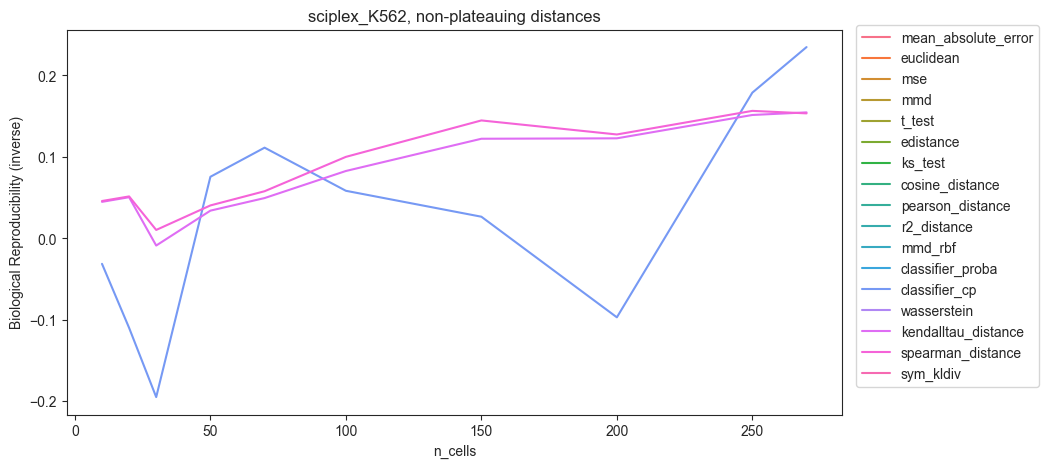

,metric,plateau_found,overall_gets_worse,plateau_start_n,pmax,total_observed_gain,threshold_mode,marginal_gain_threshold,plateau_n_values
0,mean_absolute_error,True,False,20.0,-0.058926,0.069902,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 270]"
1,euclidean,True,False,20.0,-0.053311,0.046564,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 270]"
2,mse,True,False,20.0,-0.052495,0.048569,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 270]"
3,mmd,True,False,20.0,-0.052495,0.048569,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 270]"
4,t_test,True,False,20.0,-0.063299,0.073897,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 270]"
5,edistance,True,False,20.0,-0.059440,0.051495,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 270]"
6,ks_test,True,False,20.0,-0.061860,0.078103,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 270]"
7,cosine_distance,True,False,20.0,0.017177,0.018710,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 270]"
8,pearson_distance,True,False,20.0,0.012401,0.022164,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 270]"
9,r2_distance,True,False,20.0,0.013339,0.017171,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 270]"


<Figure size 1000x500 with 0 Axes>

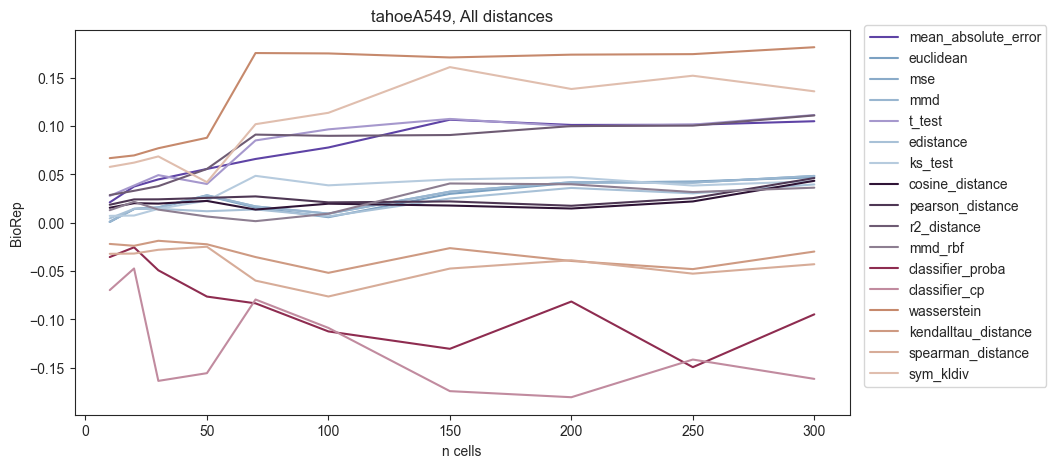

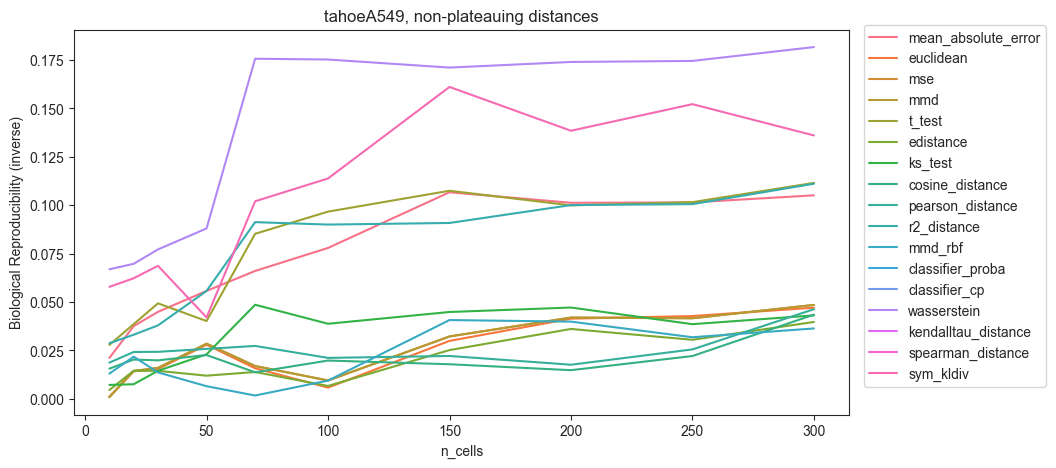

,metric,plateau_found,overall_gets_worse,plateau_start_n,pmax,total_observed_gain,threshold_mode,marginal_gain_threshold,plateau_n_values
0,mean_absolute_error,False,True,NaN,NaN,-0.083925,absolute,0.05,[]
1,euclidean,False,True,NaN,NaN,-0.045928,absolute,0.05,[]
2,mse,False,True,NaN,NaN,-0.047573,absolute,0.05,[]
3,mmd,False,True,NaN,NaN,-0.047573,absolute,0.05,[]
4,t_test,False,True,NaN,NaN,-0.083616,absolute,0.05,[]
5,edistance,False,True,NaN,NaN,-0.035143,absolute,0.05,[]
6,ks_test,False,True,NaN,NaN,-0.035895,absolute,0.05,[]
7,cosine_distance,False,True,NaN,NaN,-0.027883,absolute,0.05,[]
8,pearson_distance,False,True,NaN,NaN,-0.027602,absolute,0.05,[]
9,r2_distance,False,True,NaN,NaN,-0.082340,absolute,0.05,[]


<Figure size 1000x500 with 0 Axes>

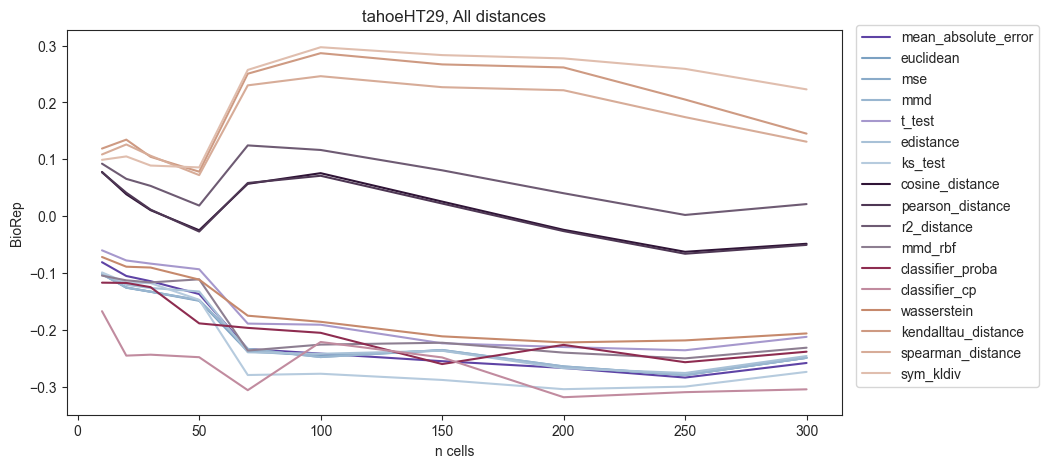

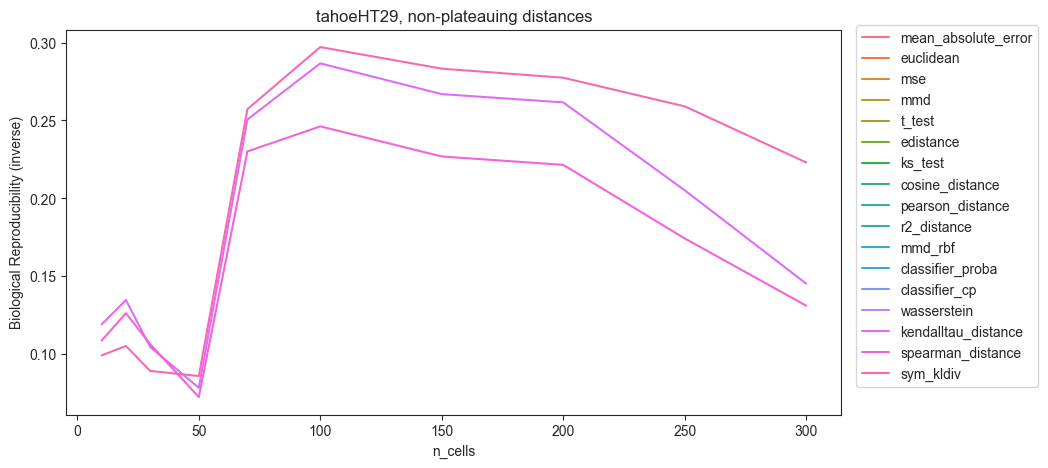

,metric,plateau_found,overall_gets_worse,plateau_start_n,pmax,total_observed_gain,threshold_mode,marginal_gain_threshold,plateau_n_values
0,mean_absolute_error,True,False,20.0,-0.211016,0.177367,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
1,euclidean,True,False,20.0,-0.213827,0.148225,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
2,mse,True,False,20.0,-0.213149,0.147012,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
3,mmd,True,False,20.0,-0.213149,0.147012,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
4,t_test,True,False,20.0,-0.171032,0.152275,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
5,edistance,True,False,20.0,-0.210023,0.146135,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
6,ks_test,True,False,20.0,-0.234167,0.175044,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
7,cosine_distance,True,False,20.0,0.005070,0.126412,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
8,pearson_distance,True,False,20.0,0.003634,0.127707,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
9,r2_distance,True,False,20.0,0.057949,0.071122,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"


<Figure size 1000x500 with 0 Axes>

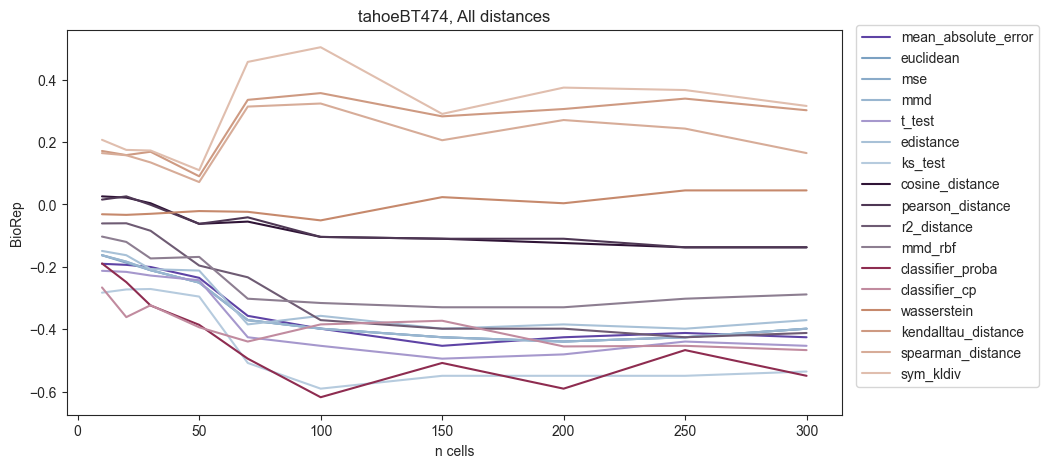

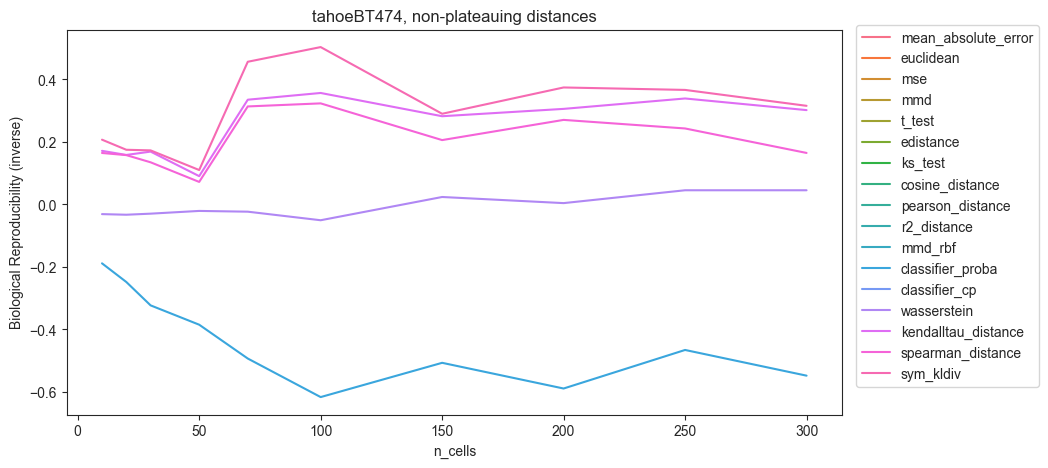

,metric,plateau_found,overall_gets_worse,plateau_start_n,pmax,total_observed_gain,threshold_mode,marginal_gain_threshold,plateau_n_values
0,mean_absolute_error,True,False,20.0,-0.344230,0.235334,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
1,euclidean,True,False,20.0,-0.344778,0.235313,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
2,mse,True,False,20.0,-0.344397,0.235313,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
3,mmd,True,False,20.0,-0.344397,0.235313,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
4,t_test,True,False,20.0,-0.381112,0.240252,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
5,edistance,True,False,20.0,-0.319161,0.221583,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
6,ks_test,True,False,20.0,-0.457431,0.252555,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
7,cosine_distance,True,False,20.0,-0.078047,0.163141,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
8,pearson_distance,True,False,20.0,-0.075107,0.152859,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"
9,r2_distance,True,False,20.0,-0.286251,0.350868,absolute,0.05,"[20, 30, 50, 70, 100, 150, 200, 250, 300]"


<Figure size 1000x500 with 0 Axes>

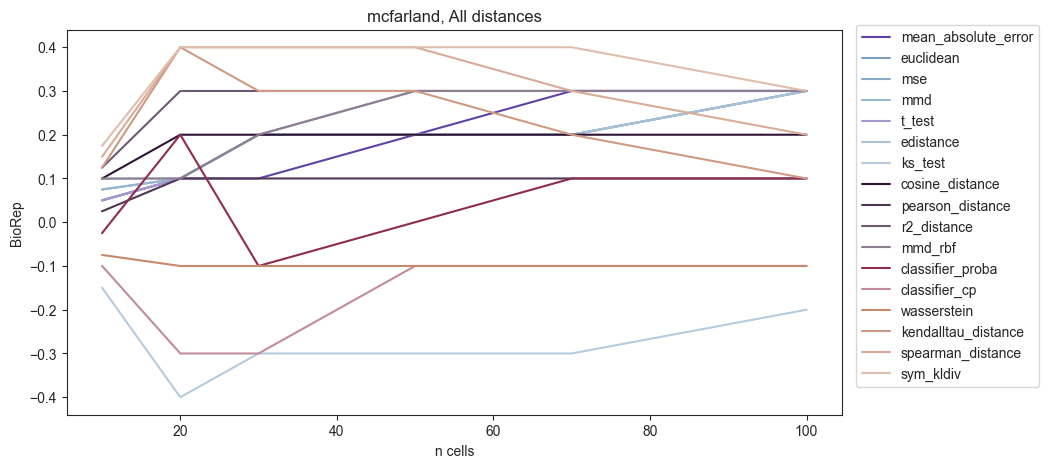

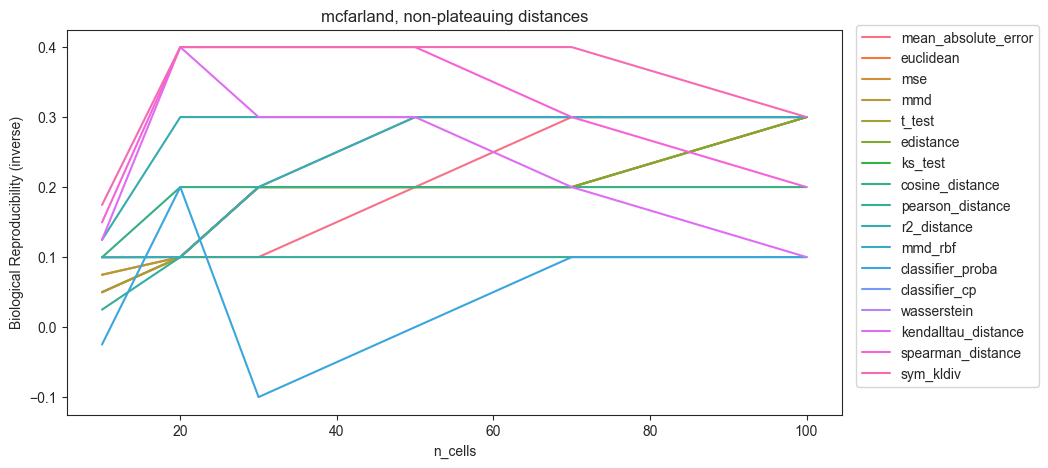

,metric,plateau_found,overall_gets_worse,plateau_start_n,pmax,total_observed_gain,threshold_mode,marginal_gain_threshold,plateau_n_values
0,mean_absolute_error,False,True,NaN,NaN,-0.250156,absolute,0.05,[]
1,euclidean,False,True,NaN,NaN,-0.250156,absolute,0.05,[]
2,mse,False,True,NaN,NaN,-0.225233,absolute,0.05,[]
3,mmd,False,True,NaN,NaN,-0.225233,absolute,0.05,[]
4,t_test,False,True,NaN,NaN,-0.250156,absolute,0.05,[]
5,edistance,False,True,NaN,NaN,-0.200311,absolute,0.05,[]
6,ks_test,True,False,30.0,-0.275,0.050467,absolute,0.05,"[30, 50, 70, 100]"
7,cosine_distance,False,True,NaN,NaN,-0.100311,absolute,0.05,[]
8,pearson_distance,False,True,NaN,NaN,-0.075078,absolute,0.05,[]
9,r2_distance,False,True,NaN,NaN,-0.175389,absolute,0.05,[]


In [89]:
# exact plotting names used in your dataframe
distances = [
    "mmd_rbf", "wasserstein", "ks_test", "r2_distance", "sym_kldiv",
    "classifier_proba", "euclidean", "cosine_distance", "mse",
    "pearson_distance", "spearman_distance", "mmd", "mean_absolute_error",
    "edistance", "classifier_cp", "t_test", "kendalltau_distance",
]

# map plotting names -> display names used in your type dict
pretty_names = {
    "edistance": "E-distance",
    "euclidean": "Euclidean",
    "ks_test": "KS statistic",
    "kendalltau_distance": "Kendall tau distance",
    "mmd": "MMD linear",
    "mse": "MSE",
    "pearson_distance": "Pearson",
    "r2_distance": "R2",
    "spearman_distance": "Spearman",
    "t_test": "T-test",
    "wasserstein": "Wasserstein",
    "classifier_cp": "classifier class projection",
    "classifier_proba": "classifier proba",
    "mmd_rbf": "MMD RBF",
    "cosine_distance": "cosine distance",
    "mean_absolute_error": "mean absolute error",
    "sym_kldiv": "symmetric KL div.",
}

# display order you want
legend_order_pretty = [
    "mean absolute error",
    "Euclidean",
    "MSE",
    "MMD linear",
    "T-test",
    "E-distance",
    "KS statistic",
    "cosine distance",
    "Pearson",
    "R2",
    "MMD RBF",
    "classifier proba",
    "classifier class projection",
    "Wasserstein",
    "Kendall tau distance",
    "Spearman",
    "symmetric KL div.",
]

# invert pretty_names so we can order plotting names by your desired legend order
pretty_to_internal = {v: k for k, v in pretty_names.items()}
legend_order = [pretty_to_internal[x] for x in legend_order_pretty]

types = {
    'E-distance':'Ia',
    'Euclidean':'Ia',
    'KS statistic':'Ia',
    'Kendall tau distance':'III',
    'MMD linear':'Ia',
    'MSE':'Ia',
    'Pearson':'II',
    'R2':'II',
    'Spearman':'III',
    'T-test':'Ib',
    'Wasserstein':'III',
    'classifier class projection':'-',
    'classifier proba':'-',
    'MMD RBF':'II',
    'cosine distance':'II',
    'mean absolute error':'Ib',
    'symmetric KL div.':'III',
}

# base colors for categories from twilight, in your desired order
type_order = ["blank", "Ia", "Ib", "II", "-", "III"]
twilight = plt.get_cmap("twilight")
type_base = dict(zip(type_order, twilight(np.linspace(0, 1, len(type_order), endpoint=False))))

from matplotlib.colors import to_rgb
import numpy as np

def blend_with_white(color, frac):
    c = np.array(to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple((1 - frac) * c + frac * white)

# group distances by type, but preserve your desired legend order within each type
type_to_distances = {t: [] for t in type_order}
for d in legend_order:
    t = types[pretty_names[d]]
    type_to_distances[t].append(d)

# build final palette dict
palette_dict = {}
for t in type_order:
    ds = type_to_distances[t]
    n = len(ds)
    fracs = np.linspace(0.0, 0.45, n) if n > 1 else [0.15]
    for d, frac in zip(ds, fracs):
        palette_dict[d] = blend_with_white(type_base[t], frac)

rows = []
for key, result in performances.items():
    dataset, n = key.rsplit("_", 1)
    for distance_name in distances:
        rows.append({
            "dataset": dataset,
            "n_cells": int(n),
            "metric": distance_name,
            "value": result[result.columns[-1]].loc[distance_name],
        })

plot_df = pd.DataFrame(rows)
plot_df['value'] = -plot_df['value']

# make hue categorical in the exact order you want
plot_df["metric"] = pd.Categorical(plot_df["metric"], categories=legend_order, ordered=True)

datasets = plot_df["dataset"].unique()
summary_dfs = []
for dataset in datasets:
    plt.figure(figsize=(10, 5))

    summary_df, curve_df = identify_pmax_by_marginal_gain(
        plot_df[plot_df.dataset == dataset],
        perf_col="value",
        metric_col="metric",
        n_col="n_cells",
        marginal_frac=0.05,
#         require_consecutive=2,
        threshold_mode="absolute",
    )
    
    dataset_df = plot_df[plot_df["dataset"] == dataset].copy()
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=dataset_df,
        x="n_cells",
        y="value",
        hue="metric",
        hue_order=legend_order,
        palette=palette_dict,
    )
    plt.ylabel("BioRep")
    plt.xlabel("n cells")
    plt_legend()
    plt.title(dataset + ', All distances')
    plt.show()
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(
        # only plot the distances which did not plateau to see what happened
        data=dataset_df[dataset_df.metric.isin(summary_df[summary_df.plateau_found == False].metric.values)],
        x='n_cells', y='value', hue='metric')
    plt.ylabel('Biological Reproducibility (inverse)')
    plt_legend()
    plt.title(dataset + ', non-plateauing distances')
    plt.show()
    
    display(summary_df)
    summary_df['dataset'] = dataset
    summary_dfs.append(summary_df)

,metric,n_datasets,n_plateau,frac_plateau,mean_plateau_start_n,median_plateau_start_n
0,ks_test,11,10,0.909091,33.000000,20.0
1,t_test,11,9,0.818182,23.333333,20.0
2,wasserstein,11,9,0.818182,23.333333,20.0
3,r2_distance,11,9,0.818182,38.888889,20.0
4,cosine_distance,11,9,0.818182,44.444444,20.0
5,pearson_distance,11,9,0.818182,44.444444,20.0
6,classifier_proba,11,9,0.818182,45.555556,30.0
7,mean_absolute_error,11,9,0.818182,46.666667,20.0
8,euclidean,11,9,0.818182,48.888889,30.0
9,mmd,11,9,0.818182,48.888889,30.0


overall_n_plateaus: 144
overall_n_total: 187
overall_mean_plateau_start_n: 44.236111111111114
overall_median_plateau_start_n: 20.0


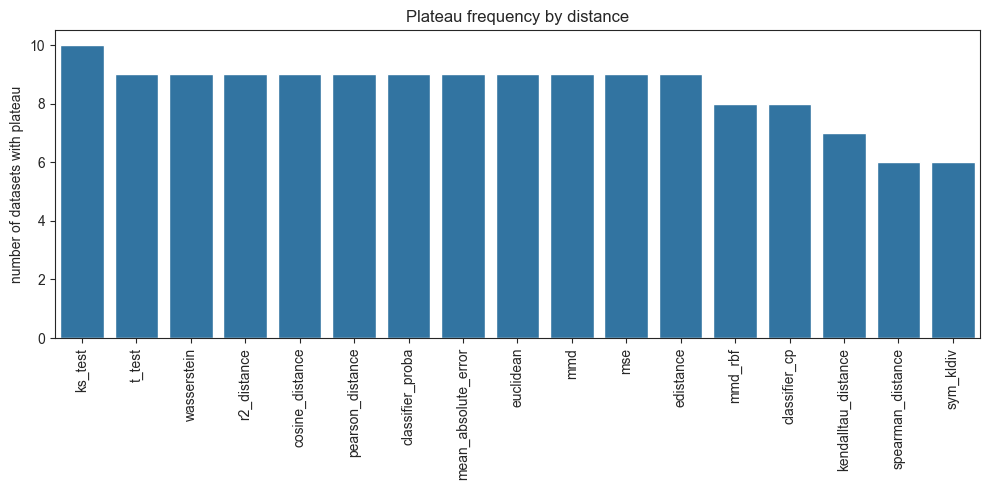

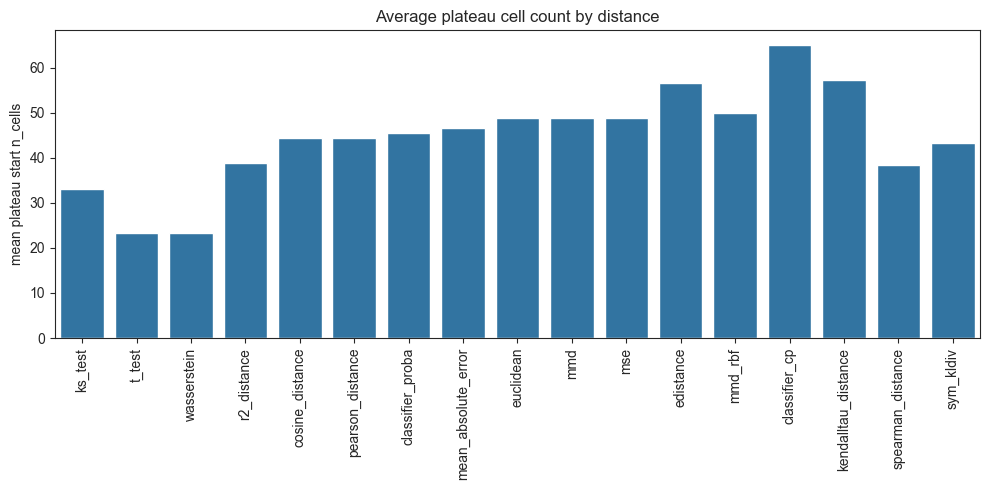

,metric,n_plateau,frac_plateau,mean_plateau_start_n
0,ks_test,10,0.909091,33.000000
1,t_test,9,0.818182,23.333333
2,wasserstein,9,0.818182,23.333333
3,r2_distance,9,0.818182,38.888889
4,cosine_distance,9,0.818182,44.444444
5,pearson_distance,9,0.818182,44.444444
6,classifier_proba,9,0.818182,45.555556
7,mean_absolute_error,9,0.818182,46.666667
8,euclidean,9,0.818182,48.888889
9,mmd,9,0.818182,48.888889


In [76]:
all_summary = pd.concat(summary_dfs, ignore_index=True)

per_metric = (
    all_summary
    .groupby("metric", as_index=False)
    .agg(
        n_datasets=("dataset", "nunique"),
        n_plateau=("plateau_found", "sum"),
        frac_plateau=("plateau_found", "mean"),
        mean_plateau_start_n=("plateau_start_n", "mean"),
        median_plateau_start_n=("plateau_start_n", "median"),
    )
    .sort_values(["n_plateau", "mean_plateau_start_n"], ascending=[False, True])
    .reset_index(drop=True)
)

display(per_metric)

# overall average plateau cell count across all dataset-distance pairs where plateau was found
overall_mean_plateau_start_n = all_summary.loc[all_summary["plateau_found"], "plateau_start_n"].mean()
overall_median_plateau_start_n = all_summary.loc[all_summary["plateau_found"], "plateau_start_n"].median()
overall_n_plateaus = all_summary["plateau_found"].sum()
overall_n_total = len(all_summary)

print("overall_n_plateaus:", overall_n_plateaus)
print("overall_n_total:", overall_n_total)
print("overall_mean_plateau_start_n:", overall_mean_plateau_start_n)
print("overall_median_plateau_start_n:", overall_median_plateau_start_n)

# plot 1: how many datasets each metric plateaued in
plt.figure(figsize=(10, 5))
sns.barplot(data=per_metric, x="metric", y="n_plateau")
plt.xticks(rotation=90)
plt.ylabel("number of datasets with plateau")
plt.xlabel("")
plt.title("Plateau frequency by distance")
plt.tight_layout()
plt.show()

# plot 2: average plateau cell count for each metric
plot_df = per_metric.dropna(subset=["mean_plateau_start_n"]).copy()

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="metric", y="mean_plateau_start_n")
plt.xticks(rotation=90)
plt.ylabel("mean plateau start n_cells")
plt.xlabel("")
plt.title("Average plateau cell count by distance")
plt.tight_layout()
plt.show()

# optional: one compact table with just the main outputs
final_table = per_metric[["metric", "n_plateau", "frac_plateau", "mean_plateau_start_n"]].copy()
display(final_table)

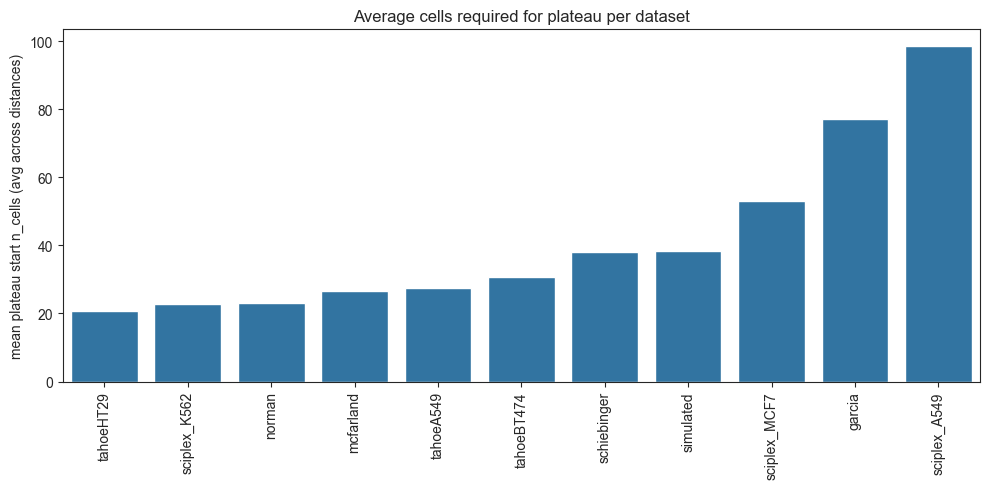

In [77]:
# average plateau cell count per dataset (averaged across distances)
per_dataset = (
    all_summary[all_summary["plateau_found"]]
    .groupby("dataset", as_index=False)
    .agg(mean_plateau_start_n=("plateau_start_n", "mean"))
    .sort_values("mean_plateau_start_n")
)

plt.figure(figsize=(10, 5))
sns.barplot(data=per_dataset, x="dataset", y="mean_plateau_start_n")
plt.xticks(rotation=90)
plt.ylabel("mean plateau start n_cells (avg across distances)")
plt.xlabel("")
plt.title("Average cells required for plateau per dataset")
plt.tight_layout()
plt.show()

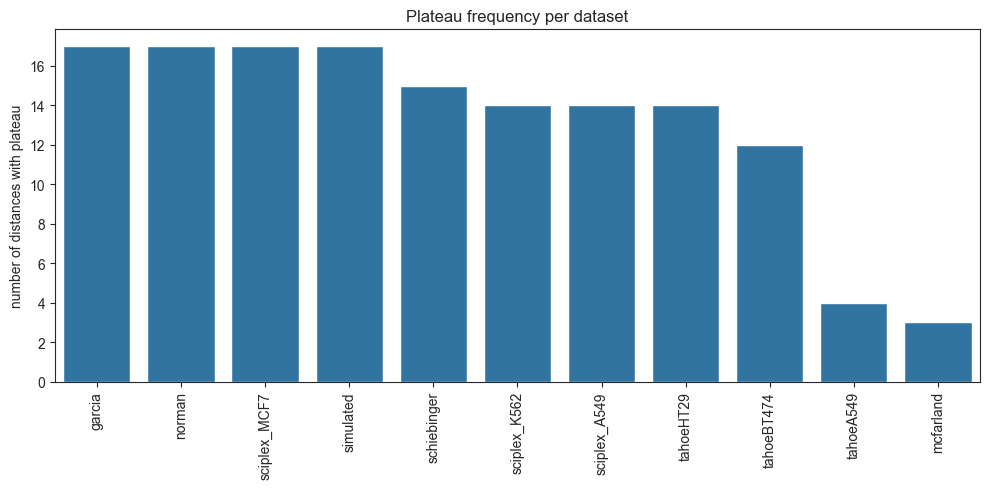

,dataset,n_plateau,frac_plateau,n_distances
0,garcia,17,1.000000,17
2,norman,17,1.000000,17
6,sciplex_MCF7,17,1.000000,17
7,simulated,17,1.000000,17
3,schiebinger,15,0.882353,17
5,sciplex_K562,14,0.823529,17
4,sciplex_A549,14,0.823529,17
10,tahoeHT29,14,0.823529,17
9,tahoeBT474,12,0.705882,17
8,tahoeA549,4,0.235294,17


In [78]:
# how many distances plateaued per dataset
per_dataset_plateau_count = (
    all_summary.groupby("dataset", as_index=False)
    .agg(
        n_plateau=("plateau_found", "sum"),
        frac_plateau=("plateau_found", "mean"),
        n_distances=("metric", "nunique"),
    )
    .sort_values("n_plateau", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=per_dataset_plateau_count, x="dataset", y="n_plateau")
plt.xticks(rotation=90)
plt.ylabel("number of distances with plateau")
plt.xlabel("")
plt.title("Plateau frequency per dataset")
plt.tight_layout()
plt.show()

display(per_dataset_plateau_count)

In [82]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns

def plot_labeled_scatter(df, x, y, label):
    plt.figure(figsize=(8, 6))
    ax = sns.scatterplot(data=df, x=x, y=y, s=120)

    texts = [
        plt.text(row[x], row[y], str(row[label]), fontsize=9)
        for _, row in df.iterrows()
    ]
    adjust_text(texts, ax=ax)

    ax.invert_yaxis()
    ax.set_axisbelow(True)
    ax.grid(True, which="major", axis="both", linestyle="-", linewidth=0.5, alpha=0.3)

    return ax

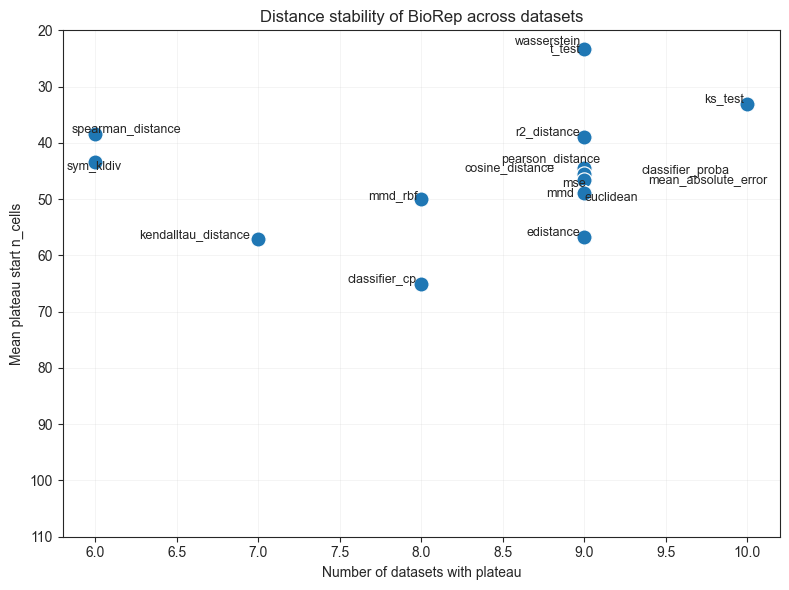

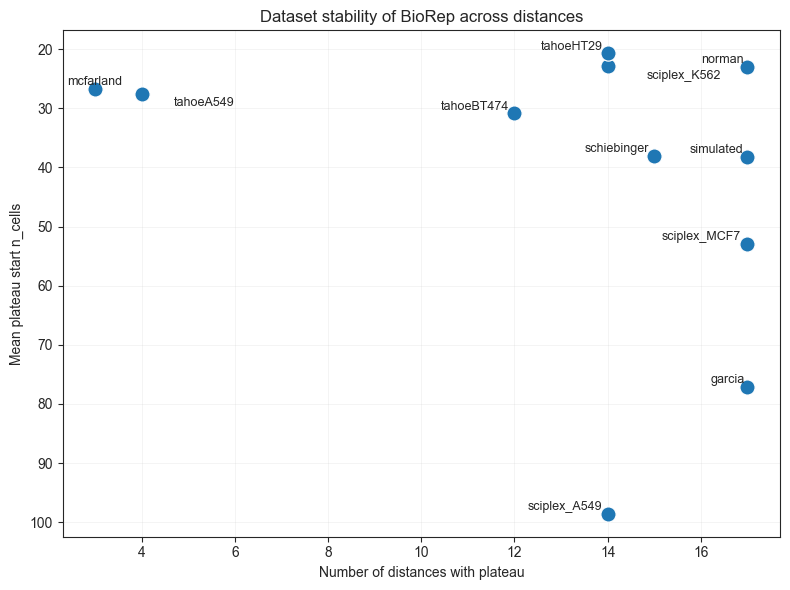

In [88]:
plot_labeled_scatter(per_metric, x="n_plateau", y="mean_plateau_start_n", label="metric")
plt.ylim(110, 20)
plt.xlabel("Number of datasets with plateau")
plt.ylabel("Mean plateau start n_cells")
plt.title("Distance stability of BioRep across datasets")
plt.tight_layout()
plt.savefig('./figures/ncells_BioRep_distances.svg')
plt.show()

plot_dataset = (
    per_dataset_plateau_count.merge(
        per_dataset[["dataset", "mean_plateau_start_n"]],
        on="dataset",
        how="left"
    )
)
plot_labeled_scatter(plot_dataset, x="n_plateau", y="mean_plateau_start_n", label="dataset")
plt.xlabel("Number of distances with plateau")
plt.ylabel("Mean plateau start n_cells")
plt.title("Dataset stability of BioRep across distances")
plt.tight_layout()
plt.savefig('./figures/ncells_BioRep_datasets.svg')
plt.show()

## effect of different seeds (different cells are subsampled)

Note that this is run with a previous version of the repo that stores results separately per seed, making this analysis possible. We have since changed the code to run multiple random seeds in one run by default to make results more robust. To reproduce these results, either use the commit hash `91354f4bc420b34e561216c498f165ee13f6c0f5` or manually change the random states to the following seed values.

In [7]:
def retrieve_individual_performances(dss_path):
    performances = {}

    for name, cfg in DATASETS.items():
        print('retrieving', f"{dss_path}/{cfg['pkl']}")
        with open(f"{dss_path}/{cfg['pkl']}", "rb") as f:
            results = pickle.load(f)

        perf_df = evaluate_on_dataset(
            results,
            cfg["annotate"],
            cfg["ground_truth"],
            optimal_distance=cfg["optimal_distance"],
            plot_performance=False
        )
        performances[name] = perf_df

    return performances

In [77]:
original_performances = retrieve_individual_performances("/lustre/scratch/users/yuge.ji/metrics/with_add_metrics_final")

retrieving /lustre/scratch/users/yuge.ji/metrics/with_add_metrics_final/sim_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/with_add_metrics_final/garcia_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/with_add_metrics_final/schiebinger_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/with_add_metrics_final/satinha_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/with_add_metrics_final/norman_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/with_add_metrics_final/spMCF7_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/with_add_metrics_final/spA549_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/with_add_metrics_final/spK562_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/with_add_metrics_final/tahoe_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/with_add_metrics_final/tahoeHT29_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/with_add_metrics_final/tahoeBT474_sub.pkl
retrieving /lustre/scratch/users/y

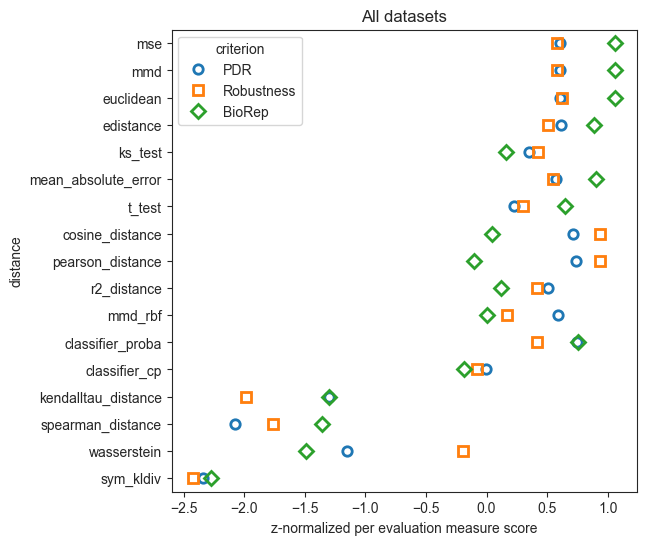

In [81]:
_, orig_df = performances_to_result_df(original_performances)

In [82]:
orig_df

,sensitivity_simulated,robustness_simulated,corr_DEProb_simulated,sensitivity_garcia,robustness_garcia,corr_pcw_garcia,sensitivity_schiebinger,robustness_schiebinger,corr_day_schiebinger,sensitivity_satinha,...,corr_dose_tahoeA549,sensitivity_tahoeHT29,robustness_tahoeHT29,corr_dose_tahoeHT29,sensitivity_tahoeBT474,robustness_tahoeBT474,corr_dose_tahoeBT474,sensitivity_mcfarland,robustness_mcfarland,corr_time_mcfarland
sym_kldiv,0.606897,0.927705,0.158604,0.9625,0.998828,0.881818,0.989744,0.999803,0.967914,0.506667,...,-0.197625,0.500952,0.887592,-0.179668,0.688889,0.959808,-0.419417,0.8500,0.998828,0.3
wasserstein,0.862069,0.986920,0.412371,0.9750,0.998828,0.854545,0.979487,0.999869,0.938885,0.633333,...,-0.201197,0.777143,0.982649,0.185536,0.940741,0.997531,-0.131313,0.8000,0.997266,-0.1
spearman_distance,0.848276,0.962782,0.489911,0.9625,0.998828,0.927273,0.989744,0.999803,0.950497,0.580000,...,-0.009643,0.464762,0.911048,-0.100665,0.644444,0.985871,-0.231267,0.8500,0.998828,0.3
kendalltau_distance,0.951724,0.995482,0.549828,0.9625,0.998828,0.963636,0.984615,0.999803,0.974943,0.593333,...,-0.026432,0.560000,0.897805,-0.128471,0.748148,0.976406,-0.335141,0.9125,0.994922,0.2
classifier_cp,0.986207,0.999643,0.613269,0.9750,0.998828,0.909091,0.979487,0.999869,0.282200,0.613333,...,0.155612,0.994286,0.999973,0.277399,0.985185,0.999588,0.350821,0.9625,0.998828,-0.1
t_test,0.986207,0.999643,0.733104,0.9625,0.998828,0.936364,0.984615,0.999803,0.884798,0.680000,...,-0.165524,0.994286,0.999927,0.192830,0.992593,0.999726,0.411577,0.9750,0.998828,0.3
mean_absolute_error,0.979310,0.999643,0.747202,0.9750,0.998828,0.927273,0.984615,0.999803,0.905271,0.680000,...,-0.156714,0.992381,0.999937,0.232153,0.992593,0.999726,0.384139,0.9750,0.998828,0.3
pearson_distance,0.986207,0.999643,0.764825,0.9750,0.998828,0.918182,0.984615,0.999803,0.465546,0.713333,...,-0.078975,0.994286,0.999973,0.014808,0.985185,0.999588,0.068596,0.9625,0.998828,0.1
cosine_distance,0.986207,0.999643,0.768349,0.9750,0.998828,0.918182,0.984615,0.999803,0.412070,0.706667,...,-0.072716,0.994286,0.999973,0.012504,0.985185,0.999588,0.068596,0.9625,0.998828,0.2
mse,0.979310,0.999643,0.778923,0.9750,0.998828,0.927273,0.984615,0.999803,0.717953,0.680000,...,-0.070728,0.994286,0.999973,0.236431,0.992593,0.999726,0.370420,0.9750,0.998828,0.3


retrieving /lustre/scratch/users/yuge.ji/metrics/seed_42/sim_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_42/garcia_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_42/schiebinger_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_42/satinha_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_42/norman_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_42/spMCF7_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_42/spA549_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_42/spK562_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_42/tahoe_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_42/tahoeHT29_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_42/tahoeBT474_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_42/mcfarland_sub.pkl


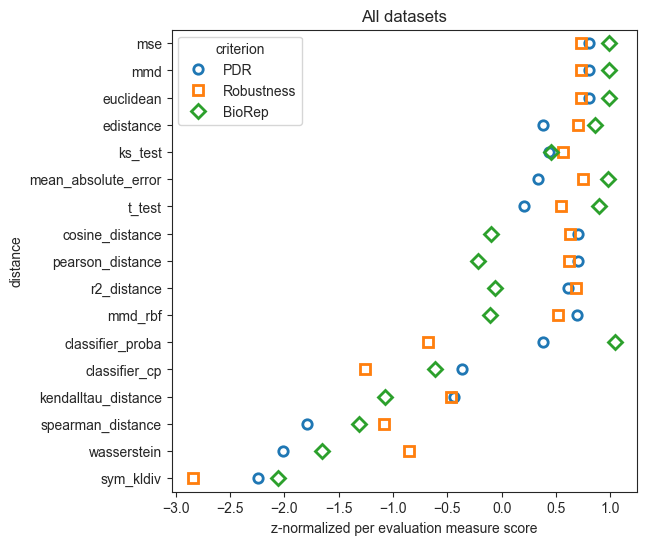

,sensitivity_simulated,robustness_simulated,corr_DEProb_simulated,sensitivity_garcia,robustness_garcia,corr_pcw_garcia,sensitivity_schiebinger,robustness_schiebinger,corr_day_schiebinger,sensitivity_satinha,...,corr_dose_tahoeA549,sensitivity_tahoeHT29,robustness_tahoeHT29,corr_dose_tahoeHT29,sensitivity_tahoeBT474,robustness_tahoeBT474,corr_dose_tahoeBT474,sensitivity_mcfarland,robustness_mcfarland,corr_time_mcfarland
wasserstein,0.855172,0.974197,0.437043,0.9625,0.998828,0.854545,0.989744,0.999803,0.923300,0.586667,...,-0.079091,0.773333,0.995764,0.180463,0.933333,0.999040,-0.078396,0.8000,0.995313,-0.1
sym_kldiv,0.544828,0.940309,0.440567,0.9750,0.998828,0.890909,0.989744,0.999803,0.941635,0.540000,...,-0.102179,0.740952,0.978712,-0.221184,0.740741,0.971879,-0.325342,0.8750,0.992188,0.3
spearman_distance,0.917241,0.994293,0.620318,0.9750,0.998828,0.918182,0.994872,0.999869,0.954469,0.520000,...,-0.046377,0.615238,0.977116,-0.110811,0.681481,0.986557,-0.090155,0.8625,0.995313,0.2
kendalltau_distance,0.979310,0.999643,0.687285,0.9750,0.998828,0.945455,0.994872,0.999869,0.965775,0.540000,...,-0.057659,0.763810,0.981025,-0.135381,0.837037,0.982442,-0.207749,0.9500,0.997266,0.1
classifier_proba,0.979310,0.999643,0.701383,0.9750,0.998828,0.909091,0.989744,0.999803,0.373568,0.713333,...,0.178240,0.994286,0.999973,0.281430,0.985185,0.999588,0.507612,0.9625,0.998828,0.2
classifier_cp,0.972414,0.999762,0.726055,0.9750,0.998828,0.827273,0.989744,0.999803,0.228419,0.486667,...,0.013718,0.994286,0.999973,0.241915,0.970370,0.999726,0.446855,0.9750,0.998828,-0.1
t_test,0.979310,0.999643,0.754251,0.9625,0.998828,0.909091,0.989744,0.999803,0.880519,0.600000,...,-0.109394,0.992381,0.999937,0.183150,0.977778,0.999588,0.439016,0.9625,0.998828,0.3
r2_distance,0.986207,0.999643,0.761300,0.9750,0.998828,0.881818,0.989744,0.999803,0.280061,0.586667,...,-0.173165,0.992381,0.999982,-0.054103,0.977778,0.999588,0.425296,0.9625,0.998828,0.3
euclidean,0.986207,0.999643,0.764825,0.9750,0.998828,0.909091,0.989744,0.999803,0.716425,0.620000,...,-0.062896,0.992381,0.999982,0.227546,0.985185,0.999588,0.397858,0.9750,0.998828,0.3
mmd,0.986207,0.999643,0.764825,0.9750,0.998828,0.909091,0.989744,0.999803,0.716425,0.620000,...,-0.061442,0.992381,0.999982,0.227546,0.985185,0.999588,0.397858,0.9750,0.998828,0.3


In [8]:
performances = retrieve_individual_performances("/lustre/scratch/users/yuge.ji/metrics/seed_42")
_, seed42_df = performances_to_result_df(performances)
seed42_df

In [84]:
# ndf = seed110_df.apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)), axis=0)
# ndf = ndf.loc[ndf.mean(axis=1).sort_values(ascending=False).index]
# ndf.mean(axis=1)

mse                    0.843312
mmd                    0.843312
euclidean              0.843032
mean_absolute_error    0.813523
edistance              0.807762
t_test                 0.789223
ks_test                0.785288
cosine_distance        0.782202
r2_distance            0.781001
pearson_distance       0.776584
mmd_rbf                0.775084
classifier_proba       0.739153
kendalltau_distance    0.602738
classifier_cp          0.583938
spearman_distance      0.468045
wasserstein            0.451612
sym_kldiv              0.306859
dtype: float64

retrieving /lustre/scratch/users/yuge.ji/metrics/seed_2026/sim_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_2026/garcia_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_2026/schiebinger_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_2026/satinha_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_2026/norman_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_2026/spMCF7_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_2026/spA549_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_2026/spK562_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_2026/tahoe_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_2026/tahoeHT29_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_2026/tahoeBT474_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_2026/mcfarland_sub.pkl


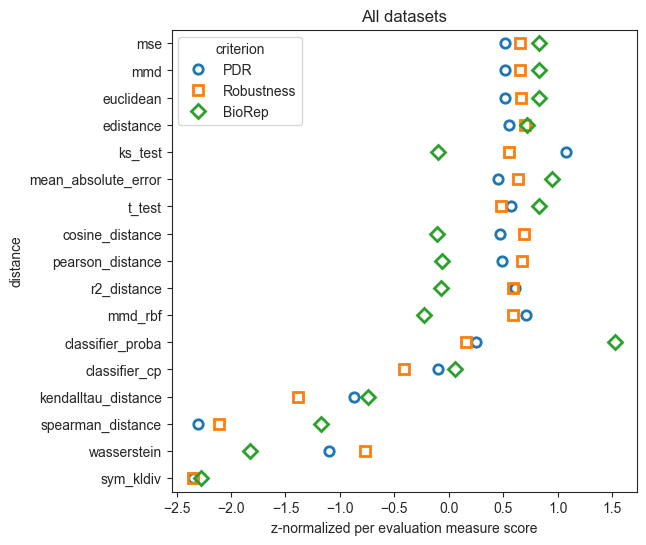

,sensitivity_simulated,robustness_simulated,corr_DEProb_simulated,sensitivity_garcia,robustness_garcia,corr_pcw_garcia,sensitivity_schiebinger,robustness_schiebinger,corr_day_schiebinger,sensitivity_satinha,...,corr_dose_tahoeA549,sensitivity_tahoeHT29,robustness_tahoeHT29,corr_dose_tahoeHT29,sensitivity_tahoeBT474,robustness_tahoeBT474,corr_dose_tahoeBT474,sensitivity_mcfarland,robustness_mcfarland,corr_time_mcfarland
sym_kldiv,0.565517,0.899168,0.200899,0.9875,0.999219,0.900000,0.989744,0.999803,0.975248,0.473333,...,-0.187175,0.720000,0.986458,-0.208186,0.807407,0.986008,-0.288104,0.8625,0.995313,0.3
wasserstein,0.937931,0.996195,0.574500,0.9750,0.998828,0.854545,0.989744,0.999803,0.938273,0.640000,...,-0.180701,0.813333,0.998522,0.199466,0.896296,0.999040,-0.060757,0.8000,0.995313,-0.1
spearman_distance,0.751724,0.984899,0.623843,0.9750,0.998828,0.890909,0.994872,0.999869,0.935523,0.433333,...,0.004969,0.445714,0.986603,-0.148818,0.688889,0.977641,-0.168551,0.8750,0.996094,0.3
kendalltau_distance,0.855172,0.992628,0.697858,0.9750,0.998828,0.954545,0.994872,0.999869,0.949580,0.460000,...,0.019744,0.573333,0.984925,-0.155674,0.755556,0.973525,-0.252826,0.9625,0.996875,0.2
classifier_cp,0.979310,0.999643,0.701383,0.9625,0.998828,0.918182,0.984615,0.999803,0.486937,0.653333,...,0.134472,0.990476,0.999728,0.291274,0.985185,0.999588,0.462534,0.9750,0.998828,-0.1
mmd,0.979310,0.999643,0.771874,0.9625,0.998828,0.918182,0.984615,0.999803,0.729565,0.660000,...,-0.034706,0.998095,0.999982,0.171167,0.985185,0.999588,0.439016,0.9625,0.998828,0.3
edistance,0.979310,0.999643,0.771874,0.9625,0.998828,0.927273,0.984615,0.999803,0.527273,0.686667,...,-0.031375,0.998095,0.999982,0.161816,0.985185,0.999588,0.370420,0.9625,0.998828,0.3
cosine_distance,0.979310,0.999643,0.771874,0.9625,0.998828,0.918182,0.984615,0.999803,0.411154,0.666667,...,-0.029495,0.998095,0.999982,-0.056078,0.985185,0.999588,0.123473,0.9625,0.998828,0.2
mse,0.979310,0.999643,0.771874,0.9625,0.998828,0.918182,0.984615,0.999803,0.729565,0.660000,...,-0.034706,0.998095,0.999982,0.171167,0.985185,0.999588,0.439016,0.9625,0.998828,0.3
t_test,0.979310,0.999643,0.771874,0.9625,0.998828,0.927273,0.989744,0.999803,0.883270,0.560000,...,-0.065436,0.994286,0.999973,0.195024,0.977778,0.999588,0.466454,0.9750,0.998828,0.3


In [9]:
performances = retrieve_individual_performances("/lustre/scratch/users/yuge.ji/metrics/seed_2026")
_, seed2026_df = performances_to_result_df(performances)
seed2026_df

retrieving /lustre/scratch/users/yuge.ji/metrics/seed_110/sim_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_110/garcia_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_110/schiebinger_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_110/satinha_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_110/norman_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_110/spMCF7_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_110/spA549_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_110/spK562_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_110/tahoe_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_110/tahoeHT29_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_110/tahoeBT474_sub.pkl
retrieving /lustre/scratch/users/yuge.ji/metrics/seed_110/mcfarland_sub.pkl


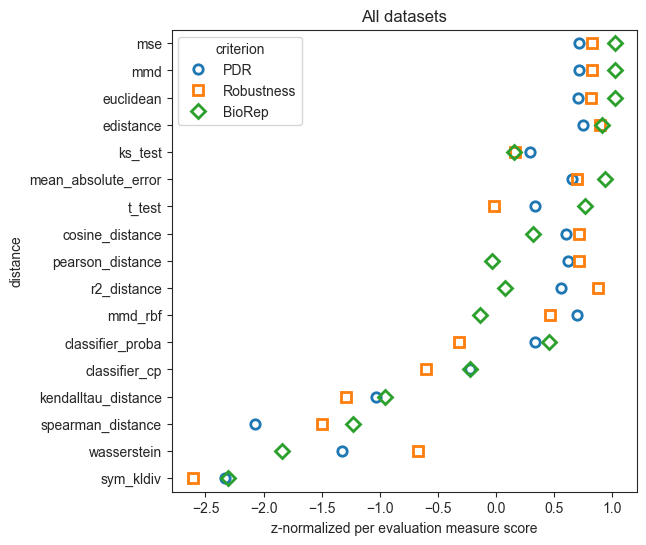

,sensitivity_simulated,robustness_simulated,corr_DEProb_simulated,sensitivity_garcia,robustness_garcia,corr_pcw_garcia,sensitivity_schiebinger,robustness_schiebinger,corr_day_schiebinger,sensitivity_satinha,...,corr_dose_tahoeA549,sensitivity_tahoeHT29,robustness_tahoeHT29,corr_dose_tahoeHT29,sensitivity_tahoeBT474,robustness_tahoeBT474,corr_dose_tahoeBT474,sensitivity_mcfarland,robustness_mcfarland,corr_time_mcfarland
sym_kldiv,0.724138,0.970868,0.313684,0.9750,0.998828,0.890909,0.984615,0.999803,0.968220,0.486667,...,-0.125070,0.487619,0.974132,-0.223844,0.637037,0.992867,-0.544850,0.8875,0.995313,0.3
wasserstein,0.917241,0.995482,0.528681,0.9750,0.998828,0.854545,0.984615,0.999803,0.938579,0.646667,...,-0.152066,0.786667,0.993669,0.221020,0.948148,0.999588,-0.127393,0.7875,0.996875,-0.1
classifier_cp,0.979310,0.999643,0.609745,0.9750,0.998828,0.909091,0.989744,0.999803,0.296257,0.353333,...,0.145781,0.992381,0.999937,0.289848,0.985185,0.999588,0.468414,0.9625,0.998828,-0.1
spearman_distance,0.889655,0.989061,0.666137,0.9625,0.998828,0.927273,0.989744,0.999803,0.953247,0.506667,...,0.033202,0.352381,0.970930,-0.138014,0.570370,0.991358,-0.397858,0.9000,0.996875,0.2
kendalltau_distance,0.972414,0.999168,0.729579,0.9625,0.998828,0.972727,0.989744,0.999803,0.966387,0.566667,...,0.012760,0.474286,0.963791,-0.136341,0.711111,0.996296,-0.419417,0.9500,0.997266,0.1
r2_distance,0.979310,0.999643,0.775398,0.9875,0.999219,0.881818,0.984615,0.999803,0.310313,0.666667,...,-0.152523,0.994286,0.999973,0.031754,0.977778,0.999588,0.425296,0.9625,0.998828,0.3
cosine_distance,0.979310,0.999643,0.782447,0.9875,0.999219,0.918182,0.984615,0.999803,0.411765,0.706667,...,-0.124425,0.996190,0.999973,0.157264,0.977778,0.999588,0.123473,0.9625,0.998828,0.3
edistance,0.979310,0.999643,0.782447,0.9875,0.999219,0.954545,0.984615,0.999803,0.515355,0.673333,...,-0.114862,0.996190,0.999973,0.275918,0.977778,0.999588,0.342981,0.9875,0.999219,0.3
euclidean,0.979310,0.999643,0.782447,0.9875,0.999219,0.945455,0.984615,0.999803,0.712147,0.666667,...,-0.116608,0.996190,0.999973,0.289848,0.985185,0.999588,0.384139,0.9750,0.998828,0.3
mse,0.979310,0.999643,0.782447,0.9875,0.999219,0.945455,0.984615,0.999803,0.706952,0.673333,...,-0.115480,0.996190,0.999973,0.289273,0.985185,0.999588,0.384139,0.9750,0.998828,0.3


In [10]:
performances = retrieve_individual_performances("/lustre/scratch/users/yuge.ji/metrics/seed_110")
_, seed110_df = performances_to_result_df(performances)
seed110_df

In [14]:
from itertools import combinations

dfs = {
    "seed_110": seed110_df,
    "seed_42": seed42_df,
    "seed_2026": seed2026_df,
}

# make sure all dataframes have the same row order before comparing
common_index = sorted(set.intersection(*(set(df.index) for df in dfs.values())))
common_columns = seed110_df.columns

aligned = {
    name: df.loc[common_index, common_columns]
    for name, df in dfs.items()
}

# pairwise Spearman correlation for each matching column
pairwise_spearman = pd.DataFrame(index=common_columns)

for a, b in combinations(aligned.keys(), 2):
    pairwise_spearman[f"{a}_vs_{b}"] = [
        aligned[a][col].corr(aligned[b][col], method="spearman")
        for col in common_columns
    ]

# group columns
groups = {
    "sensitivity": [c for c in common_columns if "sensitivity" in c],
    "robustness": [c for c in common_columns if "robustness" in c],
    "corr": [c for c in common_columns if "corr" in c],
}

# compute mean and std per group
summary = {}

for group_name, cols in groups.items():
    vals = pairwise_spearman.loc[cols].values.flatten()
    summary[group_name] = {
        "mean": pd.Series(vals).mean(),
        "std": pd.Series(vals).std(),
    }

summary_df = pd.DataFrame(summary).T
summary_df

,mean,std
sensitivity,0.626713,0.293041
robustness,0.709277,0.293918
corr,0.830625,0.159596


Yup, it's not good. While the rankings of the distances don't change too much, they do wobble a bit more than I'd like. In particular, PDR becomes pretty not robust, while BioRep does alright, as expected. Let's increase the number of random samples so this is less of a problem.